# Responsible AI for 30-Day Hospital Readmission
## Patients with diabetes — discharge-time risk stratification

**Scope:** This is retrospective educational analysis, not a validated clinical tool. The historical outcome is recorded readmission **<30 days after discharge**, not necessarily preventable or diabetes-caused readmission.

| Step | Weight | Ownership/status |
|---|---:|---|
| 1. Clinical framing | 10% | First half |
| 2. Data characterization | 10% | First half |
| 3. Experimental design | 5% | First half |
| 4. Pipelines and leakage controls | 10% | First half |
| 5. Discrimination analysis | 15% | First half |
| 6. Calibration | 8% | Second half |
| 7. Threshold selection | 8% | Second half |
| 8. Final test evaluation | 4% | Second half — test evaluated once after the policy lock |
| 9. RAI Toolbox | 30% | Second half |

**Run:** Use the project Python 3.10 environment and run cells in order. The data cell downloads the public UCI files if absent, verifies their SHA-256 hashes, and stores them in `Data/`. Generated tables, figures, split assignments, and the uncalibrated model go to `artifacts/`. All nine steps are executed; use **Restart kernel and run all** (about 12 minutes, mostly counterfactual generation in Step 9). Steps 6–9 import helpers from `utils.py` and need the Responsible AI toolbox pinned in `environment.yml`.


In [1]:
from pathlib import Path
from itertools import combinations
import csv
import hashlib
import io
import json
import platform
import urllib.request
import warnings
import zipfile
from importlib.metadata import version

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from IPython import get_ipython
get_ipython().run_line_magic("matplotlib", "inline")
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (average_precision_score, roc_auc_score, brier_score_loss,
                             confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.calibration import CalibrationDisplay

RANDOM_STATE = 42
DATA_DIR = Path("Data")
ARTIFACT_DIR = Path("artifacts")
DATA_DIR.mkdir(exist_ok=True)
ARTIFACT_DIR.mkdir(exist_ok=True)
DATA_PATH = DATA_DIR / "diabetic_data.csv"
MAPPING_PATH = DATA_DIR / "IDS_mapping.csv"
TARGET = "readmitted_30d"
PATIENT_ID = "patient_nbr"
DATA_URL = "https://archive.ics.uci.edu/static/public/296/diabetes+130-us+hospitals+for+years+1999-2008.zip"
# Prospective classroom assumptions, not selected or validated operating points.
ALERT_BUDGET_PER_1000 = 200
ALTERNATIVE_ALERT_BUDGET_PER_1000 = 250
RECALL_FLOOR = 0.85
PRECISION_ASPIRATION = 0.40
N_BOOTSTRAP = 300
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150})
set_config(display="diagram")
versions = {name: version(name) for name in [
    "numpy", "pandas", "scipy", "scikit-learn", "matplotlib", "seaborn", "joblib", "nbformat", "nbclient"
]}
versions["python"] = platform.python_version()
display(pd.Series(versions, name="Executed environment").to_frame())
(ARTIFACT_DIR / "versions.json").write_text(json.dumps(versions, indent=2) + "\n")


,Executed environment
numpy,1.26.2
pandas,1.5.3
scipy,1.13.1
scikit-learn,1.5.1
matplotlib,3.9.2
seaborn,0.13.2
joblib,1.4.2
nbformat,5.10.4
nbclient,0.10.2
python,3.10.21


233

## 1. Clinical problem framing and study objective

**Question:** At discharge, can routine encounter information identify patients with recorded diabetes at increased risk of recorded inpatient readmission in fewer than 30 days, to prioritize follow-up and diabetes education?

| Element | Study decision |
|---|---|
| Population | Age 20+, source-defined diabetes encounters, documented home/outpatient departure (including AMA) |
| Prediction time | Discharge, when encounter totals and in-hospital medication changes are available |
| Action | Nurse/case-manager review, education, appointment scheduling, or follow-up call |
| Comparison | Training-prevalence baseline versus a prespecified logistic-regression pipeline |
| Outcome | `readmitted == "<30"`; `>30` and `NO` are negative |
| Analysis unit | Eligible discharge encounter; repeated patients retained but isolated across splits |
| Success in Steps 1–5 | Quantify AP/ROC AUC improvement over baseline and uncertainty; no target performance promised |
| Later policy aspirations | Investigate 85% recall, 40% precision, and budgets of 200/250 contacts per 1,000; report infeasibility if needed |

**Eligibility:** The source already selected diabetes-coded inpatient encounters with 1–14 day stays, laboratory tests, and medication administration. Do not reselect using only the three released diagnosis fields. Age is binned: 20+ conservatively excludes 18–19-year-olds along with younger patients. Discharge codes 1, 6, 7, 8, 16, 17 define our home/outpatient follow-up cohort. Retain transfers into the index hospital and AMA departures; do not automatically remove vulnerable patients. Exclude deaths, hospice, institutional transfers, ongoing stays, and unknown destinations. This is narrower than all adult diabetes admissions.

**Why no clinician or LACE comparison:** Clinician risk judgments are not recorded, and a valid LACE comparison would require confirming that all four components can be reconstructed from this extract. These remain potential future comparisons, not evaluations this analysis supports.

**Harms and mitigations**

| Harm | Description | Mitigation |
|---|---|---|
| False negatives | Patients later readmitted are not prioritized | Report recall/FNR; keep standard discharge care for everyone |
| False positives | Extra contacts, patient burden, diverted staff time | Use an explicit total-alert budget and communicate uncertainty |
| Unequal errors | Groups may differ in missed cases or unnecessary contacts | Report subgroup metrics, event counts, uncertainty, and calibration |
| Over-reliance | Staff treat the score as definitive clinical judgment | Retain clinician review; state the intended use |
| Misread benefit | High risk is confused with preventable or intervention-responsive risk | Separate risk prediction from treatment-effect claims |

**Constraints:** Historical 1999–2008 data from institutions participating in one EHR warehouse; out-of-network readmissions uncaptured; age bands prevent exact 18+ definition; limited social information; no usable dates or hospital identifiers for temporal/site splits; no evaluated follow-up intervention. These are deidentified clinical records, not synthetic data.

**Success criteria caution:** Do not treat Brier ≤0.18 as a target. At a prevalence near 0.11, a constant prevalence prediction already has an expected Brier near 0.099. Fit the prevalence baseline on training data and score it on the designated evaluation partition.

**Illustrative patient impact — hypothetical, not a result:** If the cohort readmission rate were 11.16% and a model achieved 85% recall at 40% precision, 1,000 discharges would produce roughly **237 contacts**, of which about **95** had a recorded early readmission, about **142** did not, and about **17** early readmissions were missed. Recalculate with measured validation performance. This assumes one contact per flagged discharge and describes workload and case finding — **not readmissions prevented**.

**Limits:** CMS HRRP is broader policy context, not a standalone diabetes penalty measure; its penalties postdate these records. No causal claim follows from this analysis.

**So what?** The model would support a discharge team choosing whom to contact, not decide who deserves care. Whether that prioritization is useful depends on later calibration, workload trade-offs, and prospective intervention evaluation.

## 2. Data characterization and representativeness

**Provenance:** [UCI dataset](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008), Clore et al. (2014), DOI [10.24432/C5230J](https://doi.org/10.24432/C5230J), **CC BY 4.0**. Real deidentified clinical records, not synthetic data. The [source paper](https://pmc.ncbi.nlm.nih.gov/articles/PMC3996476/) describes the Cerner Health Facts warehouse, participating hospitals, and absent out-of-network capture.

The download's `?` values denote missing information. Literal `None` in HbA1c/glucose fields means **not measured**, not an empty cell. Medication `No` means not prescribed during the encounter. These categories remain intact.

**Ordering safeguard:** Reserve patients immediately after deterministic eligibility filtering, before outcome-based EDA. Step 2 tables/plots describe **training data only**; cohort-flow counts describe all source records without reading held-out outcome distributions. Step 3 explains the partition design.


In [2]:
EXPECTED_SHA256 = {'diabetic_data.csv': '0689e7ec031237dc63031b938805c48377748761a3b26acab621567afa24df97', 'IDS_mapping.csv': 'f1bb82b471cb34649352597572c9b1fb00bd27f77b9f5a22a03dc3eb1039749e'}
if not all((DATA_DIR / name).exists() for name in EXPECTED_SHA256):
    with urllib.request.urlopen(DATA_URL, timeout=60) as response:
        archive_bytes = response.read()
    with zipfile.ZipFile(io.BytesIO(archive_bytes)) as archive:
        for name in EXPECTED_SHA256:
            member = next(m for m in archive.namelist() if m.rsplit("/", 1)[-1] == name)
            (DATA_DIR / name).write_bytes(archive.read(member))
actual_hashes = {name: hashlib.sha256((DATA_DIR / name).read_bytes()).hexdigest()
                 for name in EXPECTED_SHA256}
assert actual_hashes == EXPECTED_SHA256, "Source differs from the documented release; investigate before proceeding."
(ARTIFACT_DIR / "data_provenance.json").write_text(json.dumps({
    "url": DATA_URL, "license": "CC BY 4.0", "sha256": actual_hashes
}, indent=2) + "\n")
raw = pd.read_csv(DATA_PATH, keep_default_na=False, na_values=["?"], low_memory=False)
assert raw["encounter_id"].is_unique
assert raw[PATIENT_ID].notna().all()
assert raw["age"].isin([f"[{n}-{n + 10})" for n in range(0, 100, 10)]).all()
assert raw["readmitted"].isin(["<30", ">30", "NO"]).all()
assert raw["time_in_hospital"].between(1, 14).all()
raw[TARGET] = raw["readmitted"].eq("<30").astype("int8")

# Parse the three independently headed mapping sections, not one flat CSV table.
mappings = {}
section = None
for row in csv.reader(MAPPING_PATH.read_text().splitlines()):
    if not row or not row[0].strip():
        continue
    if row[0].endswith("_id"):
        section = row[0]
        mappings[section] = {}
    else:
        mappings[section][int(row[0])] = row[1].strip()
discharge_map = mappings["discharge_disposition_id"]
assert set(raw["discharge_disposition_id"]) <= set(discharge_map)
discharge_audit = pd.DataFrame({
    "code": sorted(discharge_map),
    "description": [discharge_map[k] for k in sorted(discharge_map)]
})
discharge_audit["source_encounters"] = discharge_audit["code"].map(
    raw["discharge_disposition_id"].value_counts()).fillna(0).astype(int)
display(discharge_audit)
discharge_audit.to_csv(ARTIFACT_DIR / "discharge_mapping_audit.csv", index=False)


,code,description,source_encounters
0,1,Discharged to home,60234
1,2,Discharged/transferred to another short term h...,2128
2,3,Discharged/transferred to SNF,13954
3,4,Discharged/transferred to ICF,815
4,5,Discharged/transferred to another type of inpa...,1184
5,6,Discharged/transferred to home with home healt...,12902
6,7,Left AMA,623
7,8,Discharged/transferred to home under care of H...,108
8,9,Admitted as an inpatient to this hospital,21
9,10,Neonate discharged to another hospital for neo...,6


In [3]:
HOME_OUTPATIENT_CODES = {1, 6, 7, 8, 16, 17}
DEATH_HOSPICE_CODES = {11, 13, 14, 19, 20, 21}
FACILITY_CODES = {2, 3, 4, 5, 10, 15, 22, 23, 24, 27, 28, 29, 30}
# Other destinations (9, 12, 18, 25, 26) do not establish a completed,
# eligible home/outpatient discharge. Exclusion is a scope choice, not low risk.
cohort = raw.copy()
flow_rows = []
def record_flow(stage, frame, previous_count):
    flow_rows.append({"stage": stage, "removed_encounters": previous_count - len(frame),
                      "encounters": len(frame), "patients": frame[PATIENT_ID].nunique()})
record_flow("Source encounters", cohort, len(cohort))
filters = [
    ("Age 20+", ~cohort["age"].isin(["[0-10)", "[10-20)"])),
    ("Exclude death / hospice", ~cohort["discharge_disposition_id"].isin(DEATH_HOSPICE_CODES)),
    ("Exclude facility transfers", ~cohort["discharge_disposition_id"].isin(FACILITY_CODES)),
    ("Documented home / outpatient departure", cohort["discharge_disposition_id"].isin(HOME_OUTPATIENT_CODES)),
]
for stage, mask in filters:
    previous_count = len(cohort)
    cohort = cohort.loc[mask.loc[cohort.index]].copy()
    record_flow(stage, cohort, previous_count)
cohort = cohort.sort_values("encounter_id").reset_index(drop=True)
flow_table = pd.DataFrame(flow_rows)
display(flow_table)
flow_table.to_csv(ARTIFACT_DIR / "cohort_flow.csv", index=False)

# Define audits without learning any distribution-dependent transformations.
cohort["age_group"] = cohort["age"].map({
    "[20-30)": "20–39", "[30-40)": "20–39", "[40-50)": "40–59", "[50-60)": "40–59",
    "[60-70)": "60–79", "[70-80)": "60–79", "[80-90)": "80+", "[90-100)": "80+",
})
for col in ["race", "gender", "payer_code"]:
    cohort[col + "_audit"] = cohort[col].fillna("Missing").replace({"Unknown/Invalid": "Missing"})

def split_by_patient(frame, test_size):
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=RANDOM_STATE)
    left, right = next(splitter.split(frame, groups=frame[PATIENT_ID]))
    return frame.iloc[left].copy(), frame.iloc[right].copy()

train_df, holdout_df = split_by_patient(cohort, 0.30)
validation_df, test_df = split_by_patient(holdout_df, 0.50)
calibration_df, policy_df = split_by_patient(validation_df, 0.50)
partitions = {"train": train_df, "calibration": calibration_df, "policy": policy_df, "test": test_df}
patient_sets = {name: set(frame[PATIENT_ID]) for name, frame in partitions.items()}
for left, right in combinations(patient_sets, 2):
    assert patient_sets[left].isdisjoint(patient_sets[right])
assert sum(len(frame) for frame in partitions.values()) == len(cohort)
manifest = pd.concat([frame[["encounter_id", PATIENT_ID]].assign(partition=name)
                      for name, frame in partitions.items()], ignore_index=True)
assert manifest["encounter_id"].is_unique
manifest.to_csv(ARTIFACT_DIR / "split_manifest.csv", index=False)
# No test-label summary or test predictions. Membership alone is recorded.


,stage,removed_encounters,encounters,patients
0,Source encounters,0,101766,71518
1,Age 20+,852,100914,70840
2,Exclude death / hospice,2421,98493,69314
3,Exclude facility transfers,20734,77759,57460
4,Documented home / outpatient departure,4668,73091,54642


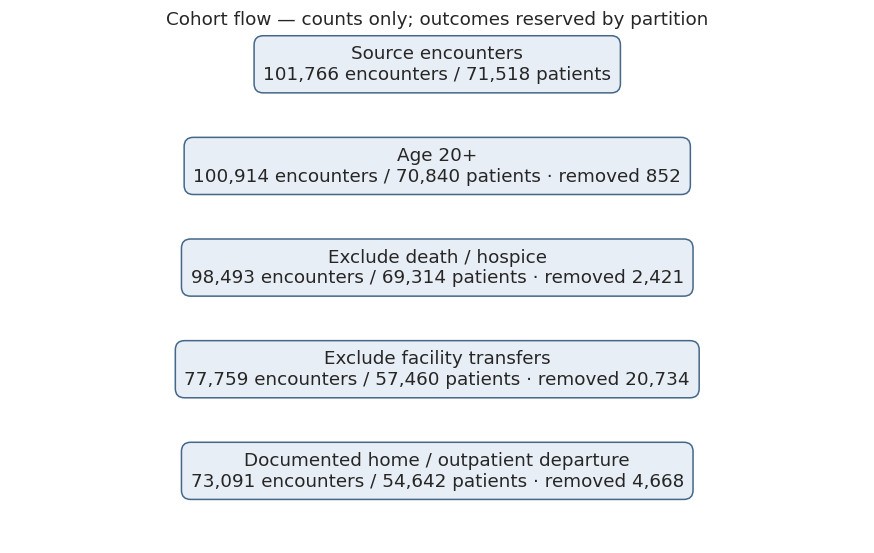

,group,encounters,patients,early_readmissions,prevalence,share_of_training,attribute
0,20–39,3562,2570,400,0.1123,0.0695,age_group
1,40–59,15764,11858,1427,0.0905,0.3076,age_group
2,60–79,24619,18667,2486,0.1010,0.4803,age_group
3,80+,7308,5543,820,0.1122,0.1426,age_group
4,Female,26697,19782,2650,0.0993,0.5209,gender_audit
5,Male,24555,18467,2483,0.1011,0.4791,gender_audit
6,Missing,1,1,0,0.0000,0.0000,gender_audit
7,AfricanAmerican,10098,7169,1052,0.1042,0.1970,race_audit
8,Asian,370,301,33,0.0892,0.0072,race_audit
9,Caucasian,37730,28277,3842,0.1018,0.7362,race_audit


,time_in_hospital,number_inpatient,number_emergency,num_medications
count,51253.00,51253.00,51253.00,51253.00
mean,4.00,0.62,0.22,15.56
std,2.78,1.28,1.09,7.90
min,1.00,0.00,0.00,1.00
25%,2.00,0.00,0.00,10.00
50%,3.00,0.00,0.00,14.00
75%,5.00,1.00,0.00,19.00
max,14.00,21.00,76.00,79.00


,missing_fraction
weight,0.966129
medical_specialty,0.476616
payer_code,0.378631
race,0.022672
diag_3,0.013170
diag_2,0.002302
diag_1,0.000137


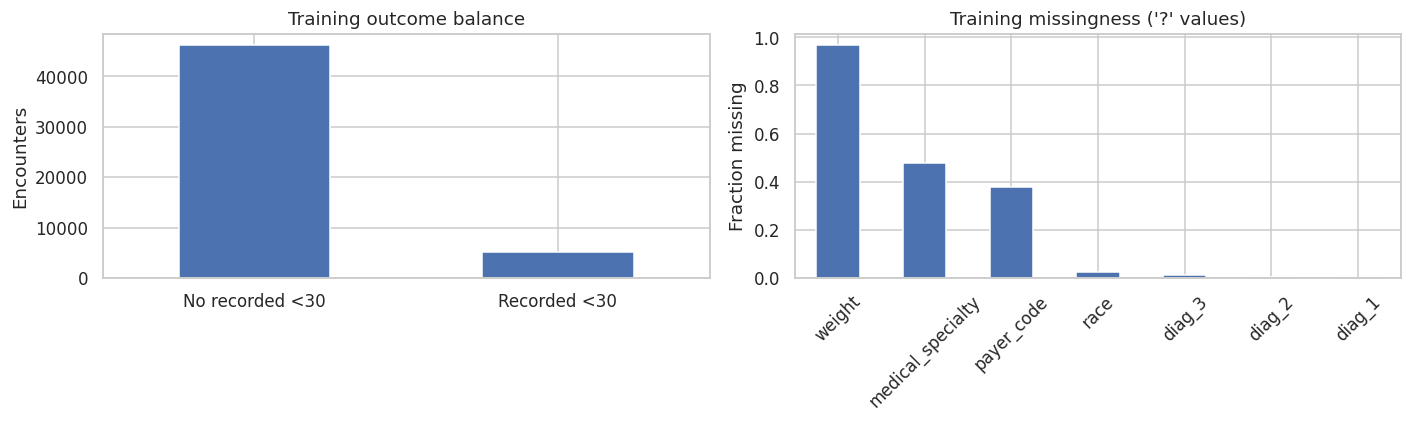

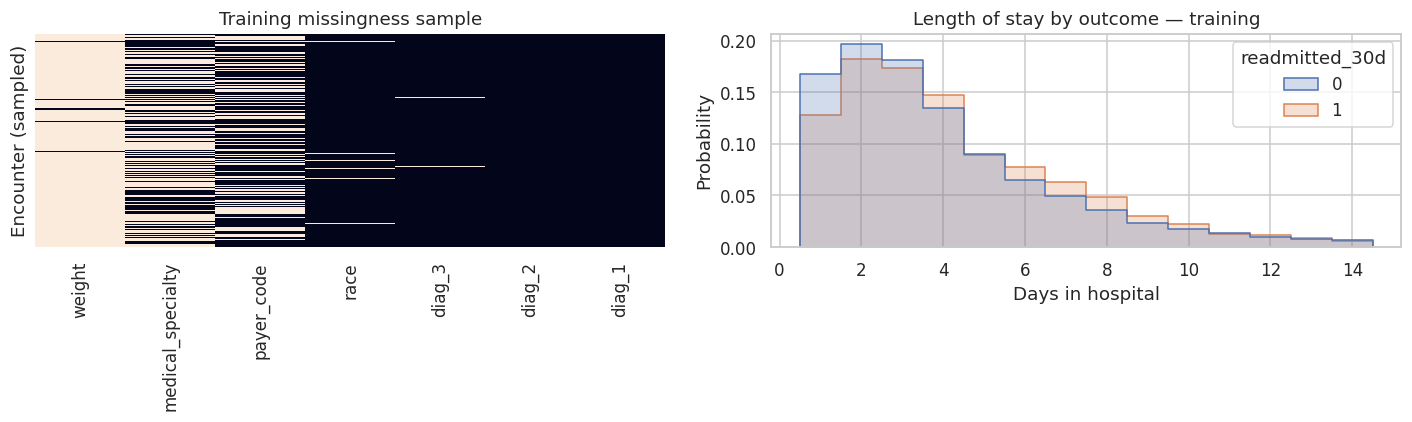

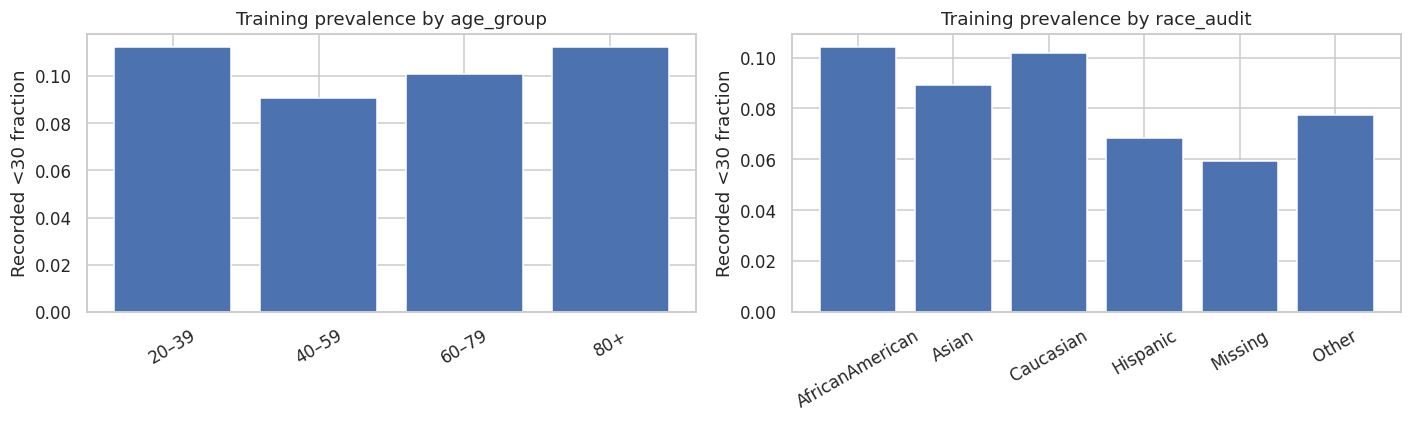

**So what?** Training contains **51,253 encounters** from **38,249 patients**, with **5,133 early readmissions (10.0%)**. Predicting 'no early readmission' for everyone would be **90.0% accurate** while finding no cases. HbA1c was recorded as not measured in **82.8%** of training encounters; this describes testing, not normal glycemic control. Weight is missing in **96.6%** and payer code in **37.9%**. Payer subgroup results must retain a missing category, and insurance is not a complete measure of socioeconomic status.

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis("off")
for i, row in flow_table.iterrows():
    y = 0.94 - i * 0.20
    ax.text(0.5, y, f"{row['stage']}\n{row['encounters']:,} encounters / {row['patients']:,} patients"
            + (f" · removed {row['removed_encounters']:,}" if i else ""),
            ha="center", va="center", transform=ax.transAxes,
            bbox={"boxstyle": "round,pad=0.5", "facecolor": "#e8eef5", "edgecolor": "#456789"})
    if i < len(flow_table) - 1:
        ax.annotate("", xy=(0.5, y-0.15), xytext=(0.5, y-0.06), xycoords="axes fraction",
                    arrowprops={"arrowstyle": "->"})
ax.set_title("Cohort flow — counts only; outcomes reserved by partition")
fig.savefig(ARTIFACT_DIR / "cohort_flow.png", bbox_inches="tight")
plt.show()

cohort_tables = []
for attribute in ["age_group", "gender_audit", "race_audit", "payer_code_audit"]:
    table = train_df.groupby(attribute, dropna=False).agg(
        encounters=(TARGET, "size"), patients=(PATIENT_ID, "nunique"),
        early_readmissions=(TARGET, "sum"), prevalence=(TARGET, "mean"))
    table["share_of_training"] = table["encounters"] / len(train_df)
    table = table.reset_index().rename(columns={attribute: "group"}).assign(attribute=attribute)
    cohort_tables.append(table)
training_cohort_table = pd.concat(cohort_tables, ignore_index=True)
display(training_cohort_table.round(4))
training_cohort_table.to_csv(ARTIFACT_DIR / "training_cohort_table.csv", index=False)
display(train_df[["time_in_hospital", "number_inpatient", "number_emergency", "num_medications"]]
        .describe(percentiles=[0.25, 0.5, 0.75]).round(2))

missingness = train_df[raw.columns].isna().mean().sort_values(ascending=False)
display(missingness[missingness > 0].rename("missing_fraction").to_frame())
missingness.rename("missing_fraction").to_csv(ARTIFACT_DIR / "training_missingness.csv")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
train_df[TARGET].map({0: "No recorded <30", 1: "Recorded <30"}).value_counts().plot.bar(ax=axes[0], rot=0)
axes[0].set(title="Training outcome balance", ylabel="Encounters", xlabel="")
missingness[missingness > 0].plot.bar(ax=axes[1], rot=45)
axes[1].set(title="Training missingness ('?' values)", ylabel="Fraction missing")
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "training_balance_missingness.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
missing_columns = missingness[missingness > 0].index
sns.heatmap(train_df.sample(n=min(400, len(train_df)), random_state=RANDOM_STATE)[missing_columns].isna(),
            cbar=False, yticklabels=False, ax=axes[0])
axes[0].set(title="Training missingness sample", ylabel="Encounter (sampled)")
sns.histplot(data=train_df, x="time_in_hospital", hue=TARGET, discrete=True,
             stat="probability", common_norm=False, element="step", ax=axes[1])
axes[1].set(title="Length of stay by outcome — training", xlabel="Days in hospital")
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "training_feature_distributions.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, attribute in zip(axes, ["age_group", "race_audit"]):
    subset = training_cohort_table.query("attribute == @attribute")
    ax.bar(subset["group"], subset["prevalence"])
    ax.tick_params(axis="x", rotation=30)
    ax.set(title=f"Training prevalence by {attribute}", ylabel="Recorded <30 fraction")
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "training_subgroup_prevalence.png", bbox_inches="tight")
plt.show()

training_prevalence = train_df[TARGET].mean()
display(Markdown(
    f"**So what?** Training contains **{len(train_df):,} encounters** from **{train_df[PATIENT_ID].nunique():,} patients**, "
    f"with **{train_df[TARGET].sum():,} early readmissions ({training_prevalence:.1%})**. "
    f"Predicting 'no early readmission' for everyone would be **{1-training_prevalence:.1%} accurate** while finding no cases. "
    f"HbA1c was recorded as not measured in **{train_df['A1Cresult'].eq('None').mean():.1%}** of training encounters; "
    "this describes testing, not normal glycemic control. "
    f"Weight is missing in **{train_df['weight'].isna().mean():.1%}** and payer code in **{train_df['payer_code'].isna().mean():.1%}**. "
    "Payer subgroup results must retain a missing category, and insurance is not a complete measure of socioeconomic status."
))


**Representativeness and label limitations:** These are selected 1999–2008 diabetes-coded encounters from institutions contributing to one EHR warehouse, not a random national sample. Out-of-network readmissions are absent; `NO` is no recorded readmission, not guaranteed absence of all readmission. The public labels do not separately identify preventable/unplanned events or resolve the exact day-30 boundary. The study excludes stays outside 1–14 days and our outpatient eligibility further excludes facility care and uncertain destinations. Results cannot establish generalization to modern hospitals or Spain. Repeated encounters are correlated and represent an encounter-weighted workload question; frequent users contribute more observations.


## 3. Experimental design and splits 

Patients were assigned **before training EDA** using nested `GroupShuffleSplit` with seed 42, in encounter-ID sorted input order. IDs are grouping keys, not predictors or timestamps. Membership is saved in `artifacts/split_manifest.csv`; no resampling is applied.

| Partition | Intended patient share | Permitted use |
|---|---:|---|
| Train | 70% | EDA, feature rationale, preprocessing, model fitting |
| Calibration validation | 7.5% | Group later fits calibration only |
| Policy validation | 7.5% | Prespecified model discrimination now; threshold selection later |
| Final test | 15% | One evaluation after full model and threshold lock |

**Advantage:** Calibration fitting and policy selection use **different patients**. No model tuning follows policy-validation results in this first half; this avoids repeatedly optimizing to the evaluation set. If model selection is later introduced, use patient-group-aware CV within training data, not either holdout. Final-test labels are retained in memory as part of the partition but are not summarized, scored, or used for decisions.

These splits are not stratified; encounter proportions and prevalence can differ. No favorable seed was selected. The public CSV lacks suitable date/hospital identifiers for genuine temporal/site splits; this evaluates held-out patients within the same historical source, not future deployment.


In [5]:
split_summary = pd.DataFrame([
    {"partition": name, "encounters": len(frame), "patients": frame[PATIENT_ID].nunique(),
     "patient_fraction": frame[PATIENT_ID].nunique() / cohort[PATIENT_ID].nunique()}
    for name, frame in partitions.items()
])
display(split_summary.round(4))
split_summary.to_csv(ARTIFACT_DIR / "split_sizes.csv", index=False)
display(Markdown("**So what?** All six pairwise patient-overlap checks passed. "
                 "A patient cannot appear on both sides of an evaluation, even when they have multiple admissions. "
                 "Calibration and policy data remain distinct; no final-test performance has been computed."))


,partition,encounters,patients,patient_fraction
0,train,51253,38249,0.700
1,calibration,5422,4098,0.075
2,policy,5552,4098,0.075
3,test,10864,8197,0.150


**So what?** All six pairwise patient-overlap checks passed. A patient cannot appear on both sides of an evaluation, even when they have multiple admissions. Calibration and policy data remain distinct; no final-test performance has been computed.

## 4. Pipelines, baselines and leakage controls

**Prespecified model:** Unweighted L2 logistic regression, `C=1`, `lbfgs`, maximum 2,000 iterations. No hyperparameter search, feature selection by holdout performance, synthetic balancing, or interactions. This provides an interpretable initial benchmark rather than a claim of optimal prediction.

Eight numeric features describe utilization and the index encounter; nine categorical features cover demographics, admission context, HbA1c testing, and treatment. Race/gender are included in this research benchmark for transparent audit, not asserted to be biologic causes or approved deployment inputs. Payer is retained **for auditing only**. Missing payer/weight and high-cardinality diagnosis/specialty features are not added opportunistically. The dictionary below documents every model input and principal exclusions.

Numeric imputation/scaling and categorical imputation/encoding are fitted inside the training-only pipeline. Literal not-tested/not-prescribed categories remain categories; integer-coded admission fields are strings, not continuous quantities. Missing race remains missing in the audit even when the model imputes it.


In [6]:
numeric_features = ["time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
                    "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses"]
categorical_features = ["age", "race", "gender", "admission_type_id", "admission_source_id",
                        "A1Cresult", "insulin", "change", "diabetesMed"]
feature_columns = numeric_features + categorical_features
feature_meanings = {
    "time_in_hospital": "Index stay duration, 1–14 days",
    "num_lab_procedures": "Laboratory tests during index encounter",
    "num_procedures": "Non-laboratory procedures during index encounter",
    "num_medications": "Distinct generic medications administered during encounter",
    "number_outpatient": "Outpatient visits during preceding year",
    "number_emergency": "Emergency visits during preceding year (not six months)",
    "number_inpatient": "Inpatient visits during preceding year",
    "number_diagnoses": "Number of diagnoses entered for index encounter",
    "age": "Released 10-year age band; encoded categorically",
    "race": "Recorded race category; potential proxy and audit attribute",
    "gender": "Recorded gender category; audit attribute",
    "admission_type_id": "Admission context, e.g. emergency/elective; nominal code",
    "admission_source_id": "Referral/transfer source; nominal code",
    "A1Cresult": "HbA1c result band; None = not measured, not normal",
    "insulin": "No/Steady/Up/Down during encounter, not home adherence",
    "change": "Any recorded change in diabetes medication during encounter",
    "diabetesMed": "Any diabetes medication prescribed during encounter",
}
dictionary_rows = [{"feature": name, "role": "predictor", "type": "numeric" if name in numeric_features else "categorical",
                    "meaning": feature_meanings[name], "availability": "By discharge",
                    "missing_handling": "Training median" if name in numeric_features else "Training mode for ?; preserve literal categories"}
                   for name in feature_columns]
for name, role, reason in [
    (PATIENT_ID, "grouping only", "Keep patients disjoint; never input to model"),
    ("encounter_id", "manifest only", "Unique encounter; not a timestamp or predictor"),
    ("readmitted", "label only", "Source outcome; excluded from X"),
    (TARGET, "target only", "1 for <30; 0 otherwise"),
    ("payer_code", "audit only", "Insurance proxy; missingness retained in audit"),
    ("discharge_disposition_id", "eligibility only", "Defines follow-up pathway; excluded from X"),
    ("weight", "excluded", "Sparse measurement; not required by prespecified model"),
    ("medical_specialty", "excluded", "High-cardinality practice information; omitted for initial benchmark"),
    ("diag_1 / diag_2 / diag_3", "excluded", "Limited diagnosis extract; no new diabetes filter or code-based feature search"),
]:
    dictionary_rows.append({"feature": name, "role": role, "type": "see source", "meaning": reason,
                            "availability": "Outcome after discharge" if role in ["target only", "label only"] else "By discharge",
                            "missing_handling": "Not part of model"})
feature_dictionary = pd.DataFrame(dictionary_rows)
display(feature_dictionary)
feature_dictionary.to_csv(ARTIFACT_DIR / "feature_dictionary.csv", index=False)

# Fixed semantic conversion, not a learned transformation; preserve true NaNs.
for frame in partitions.values():
    for col in categorical_features:
        frame[col] = frame[col].map(lambda value: str(value) if pd.notna(value) else np.nan).astype(object)
assert not {TARGET, "readmitted", PATIENT_ID, "encounter_id"} & set(feature_columns)

numeric_pipeline = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
categorical_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])
model = Pipeline([
    ("preprocess", preprocessor),
    ("classifier", LogisticRegression(C=1.0, solver="lbfgs", max_iter=2000, random_state=RANDOM_STATE)),
])
X_train, y_train = train_df[feature_columns], train_df[TARGET]
X_cal, y_cal = calibration_df[feature_columns], calibration_df[TARGET]
X_policy, y_policy = policy_df[feature_columns], policy_df[TARGET]
assert y_train.nunique() == y_policy.nunique() == 2
baseline = DummyClassifier(strategy="prior").fit(X_train, y_train)
with warnings.catch_warnings():
    warnings.simplefilter("error", ConvergenceWarning)
    model.fit(X_train, y_train)
assert np.isfinite(model.predict_proba(X_train.iloc[:10])).all()
display(model)
print("Converged iterations:", model.named_steps["classifier"].n_iter_.tolist())
print("Encoded feature count:", len(model.named_steps["preprocess"].get_feature_names_out()))
joblib.dump(model, ARTIFACT_DIR / "uncalibrated_logistic.joblib")
joblib.dump(baseline, ARTIFACT_DIR / "prevalence_baseline.joblib")


,feature,role,type,meaning,availability,missing_handling
0,time_in_hospital,predictor,numeric,"Index stay duration, 1–14 days",By discharge,Training median
1,num_lab_procedures,predictor,numeric,Laboratory tests during index encounter,By discharge,Training median
2,num_procedures,predictor,numeric,Non-laboratory procedures during index encounter,By discharge,Training median
3,num_medications,predictor,numeric,Distinct generic medications administered duri...,By discharge,Training median
4,number_outpatient,predictor,numeric,Outpatient visits during preceding year,By discharge,Training median
5,number_emergency,predictor,numeric,Emergency visits during preceding year (not si...,By discharge,Training median
6,number_inpatient,predictor,numeric,Inpatient visits during preceding year,By discharge,Training median
7,number_diagnoses,predictor,numeric,Number of diagnoses entered for index encounter,By discharge,Training median
8,age,predictor,categorical,Released 10-year age band; encoded categorically,By discharge,Training mode for ?; preserve literal categories
9,race,predictor,categorical,Recorded race category; potential proxy and au...,By discharge,Training mode for ?; preserve literal categories


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_outpatient',
                                                   'number_emergency',
                                                   'number_inpatient',
                                                   'number_diagnoses']),
                                                 ('categorical',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['age', 'race', 'gender',
                                                   'admission_type_id',
                                                   'admission_source_id',
                                                   'A1Cresult', 'insulin',
                                                   'change',
                                                   'diabetesMed'])])),
                ('classifier',
                 LogisticRegression(max_iter=2000, random_state=42))])

Converged iterations: [27]
Encoded feature count: 61


['artifacts/prevalence_baseline.joblib']

**So what?** The baseline asks whether patient-level information helps more than knowing the training readmission rate. Logistic regression can assign different risks but does not demonstrate causation, treatment benefit, or performance superior to clinicians. All encounter summaries are appropriate only for the discharge-time question. A later admission-time model would require different inputs and a new design. Calibration is deliberately not fitted yet.


## 5. Metrics and discrimination analysis

**Primary metric:** Average precision (AP), compared with policy-set prevalence. AP is not trapezoidal PR AUC. ROC AUC complements AP; accuracy alone would reward predicting the majority class. No decision threshold is selected or evaluated here.

**Uncertainty:** 300 deterministic patient-cluster bootstrap replicates, sampling patients with replacement and carrying all their evaluation encounters together. Percentile 95% intervals condition on the fitted model; they do not include model-training uncertainty. The baseline and model use the same draws for paired metric differences. Single-class replicates are excluded with the valid count reported; a point metric is undefined for single-class groups. These exploratory intervals are not multiplicity-adjusted.

**Subgroups fixed before seeing results:** Age 20–39/40–59/60–79/80+, recorded gender, recorded race, and each payer category including missing. Small groups remain visible. Fewer than 20 distinct patients contributing positive encounters or 20 contributing negative encounters is a caution flag, not a statistical reliability guarantee. A patient may contribute both outcomes, so these patient counts can overlap. Encounter counts remain the workload denominator; bootstrap resampling remains patient-level. Subgroup AP depends on prevalence, so raw AP gaps do not establish unfairness or its cause.


,model,AP,AP_low,AP_high,ROC_AUC,ROC_low,ROC_high,valid_bootstraps
0,Prevalence baseline,0.1110,0.1004,0.1228,0.5000,0.5000,0.5000,300
1,Logistic regression,0.2500,0.1966,0.3009,0.6715,0.6385,0.7008,300
2,Logistic minus baseline,0.1391,0.0951,0.1824,0.1715,0.1385,0.2008,300


Policy validation: 5,552 encounters; 616 positives; prevalence 11.10%


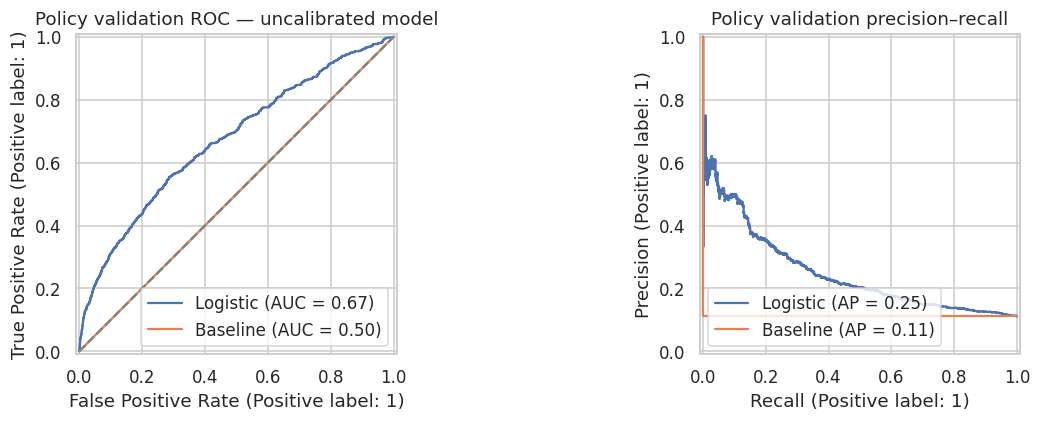

In [7]:
def discrimination_metrics(y, scores):
    y, scores = np.asarray(y), np.asarray(scores)
    if np.unique(y).size < 2:
        return np.array([np.nan, np.nan])
    return np.array([average_precision_score(y, scores), roc_auc_score(y, scores)])

def cluster_metric_intervals(y, scores, patient_ids, comparison=None):
    """Encounter-weighted metrics; patient-level resampling preserves repeat visits."""
    y, scores = np.asarray(y), np.asarray(scores)
    point = discrimination_metrics(y, scores)
    if comparison is not None:
        comparison = np.asarray(comparison)
        point = point - discrimination_metrics(y, comparison)
    if np.unique(y).size < 2:
        return point, np.full(2, np.nan), np.full(2, np.nan), 0
    _, group_index = np.unique(np.asarray(patient_ids), return_inverse=True)
    members = [np.flatnonzero(group_index == k) for k in range(group_index.max() + 1)]
    rng = np.random.default_rng(RANDOM_STATE)
    draws = []
    for _ in range(N_BOOTSTRAP):
        index = np.concatenate([members[k] for k in rng.integers(0, len(members), size=len(members))])
        values = discrimination_metrics(y[index], scores[index])
        if comparison is not None:
            values -= discrimination_metrics(y[index], comparison[index])
        if np.isfinite(values).all():
            draws.append(values)
    if not draws:
        return point, np.full(2, np.nan), np.full(2, np.nan), 0
    low, high = np.quantile(draws, [0.025, 0.975], axis=0)
    return point, low, high, len(draws)

p_policy_raw = model.predict_proba(X_policy)[:, list(model.classes_).index(1)]
p_policy_baseline = baseline.predict_proba(X_policy)[:, list(baseline.classes_).index(1)]
metric_rows = []
for name, scores, comparator in [
    ("Prevalence baseline", p_policy_baseline, None),
    ("Logistic regression", p_policy_raw, None),
    ("Logistic minus baseline", p_policy_raw, p_policy_baseline),
]:
    point, low, high, valid = cluster_metric_intervals(y_policy, scores, policy_df[PATIENT_ID], comparator)
    metric_rows.append({"model": name, "AP": point[0], "AP_low": low[0], "AP_high": high[0],
                        "ROC_AUC": point[1], "ROC_low": low[1], "ROC_high": high[1], "valid_bootstraps": valid})
metrics_table = pd.DataFrame(metric_rows)
display(metrics_table.round(4))
metrics_table.to_csv(ARTIFACT_DIR / "policy_discrimination.csv", index=False)
print(f"Policy validation: {len(y_policy):,} encounters; {y_policy.sum():,} positives; prevalence {y_policy.mean():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, scores in [("Logistic", p_policy_raw), ("Baseline", p_policy_baseline)]:
    RocCurveDisplay.from_predictions(y_policy, scores, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_policy, scores, name=name, ax=axes[1])
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_title("Policy validation ROC — uncalibrated model")
axes[1].set_title("Policy validation precision–recall")
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "policy_roc_pr.png", bbox_inches="tight")
plt.show()


,attribute,group,encounters,patients,positives,positive_patients,negative_patients,prevalence,AP,AP_low,AP_high,ROC_AUC,ROC_low,ROC_high,valid_bootstraps,caution
0,age_group,20–39,345,250,42,28,244,0.1217,0.2506,0.1244,0.4223,0.6697,0.5654,0.7465,300,
1,age_group,40–59,1754,1272,203,128,1240,0.1157,0.3211,0.2251,0.4085,0.7314,0.6741,0.7743,300,
2,age_group,60–79,2698,2047,290,237,1941,0.1075,0.2449,0.1809,0.3190,0.6599,0.6152,0.6999,300,
3,age_group,80+,755,575,81,71,540,0.1073,0.1395,0.1023,0.1883,0.5717,0.5028,0.6360,300,
4,gender_audit,Female,2879,2104,330,228,2026,0.1146,0.2893,0.2157,0.3554,0.6980,0.6522,0.7358,300,
5,gender_audit,Male,2673,1995,286,235,1896,0.1070,0.2021,0.1672,0.2535,0.6401,0.6043,0.6800,300,
6,race_audit,AfricanAmerican,1111,769,127,79,750,0.1143,0.3258,0.1815,0.4333,0.7386,0.6613,0.7883,300,
7,race_audit,Asian,30,26,1,1,25,0.0333,0.0370,0.0294,0.1386,0.1034,0.0000,0.2435,187,Small / single-class patient support
8,race_audit,Caucasian,4058,3020,449,352,2877,0.1106,0.2307,0.1867,0.2822,0.6582,0.6224,0.6888,300,
9,race_audit,Hispanic,141,102,21,13,99,0.1489,0.4301,0.1102,0.6341,0.7901,0.5914,0.8880,300,Small / single-class patient support


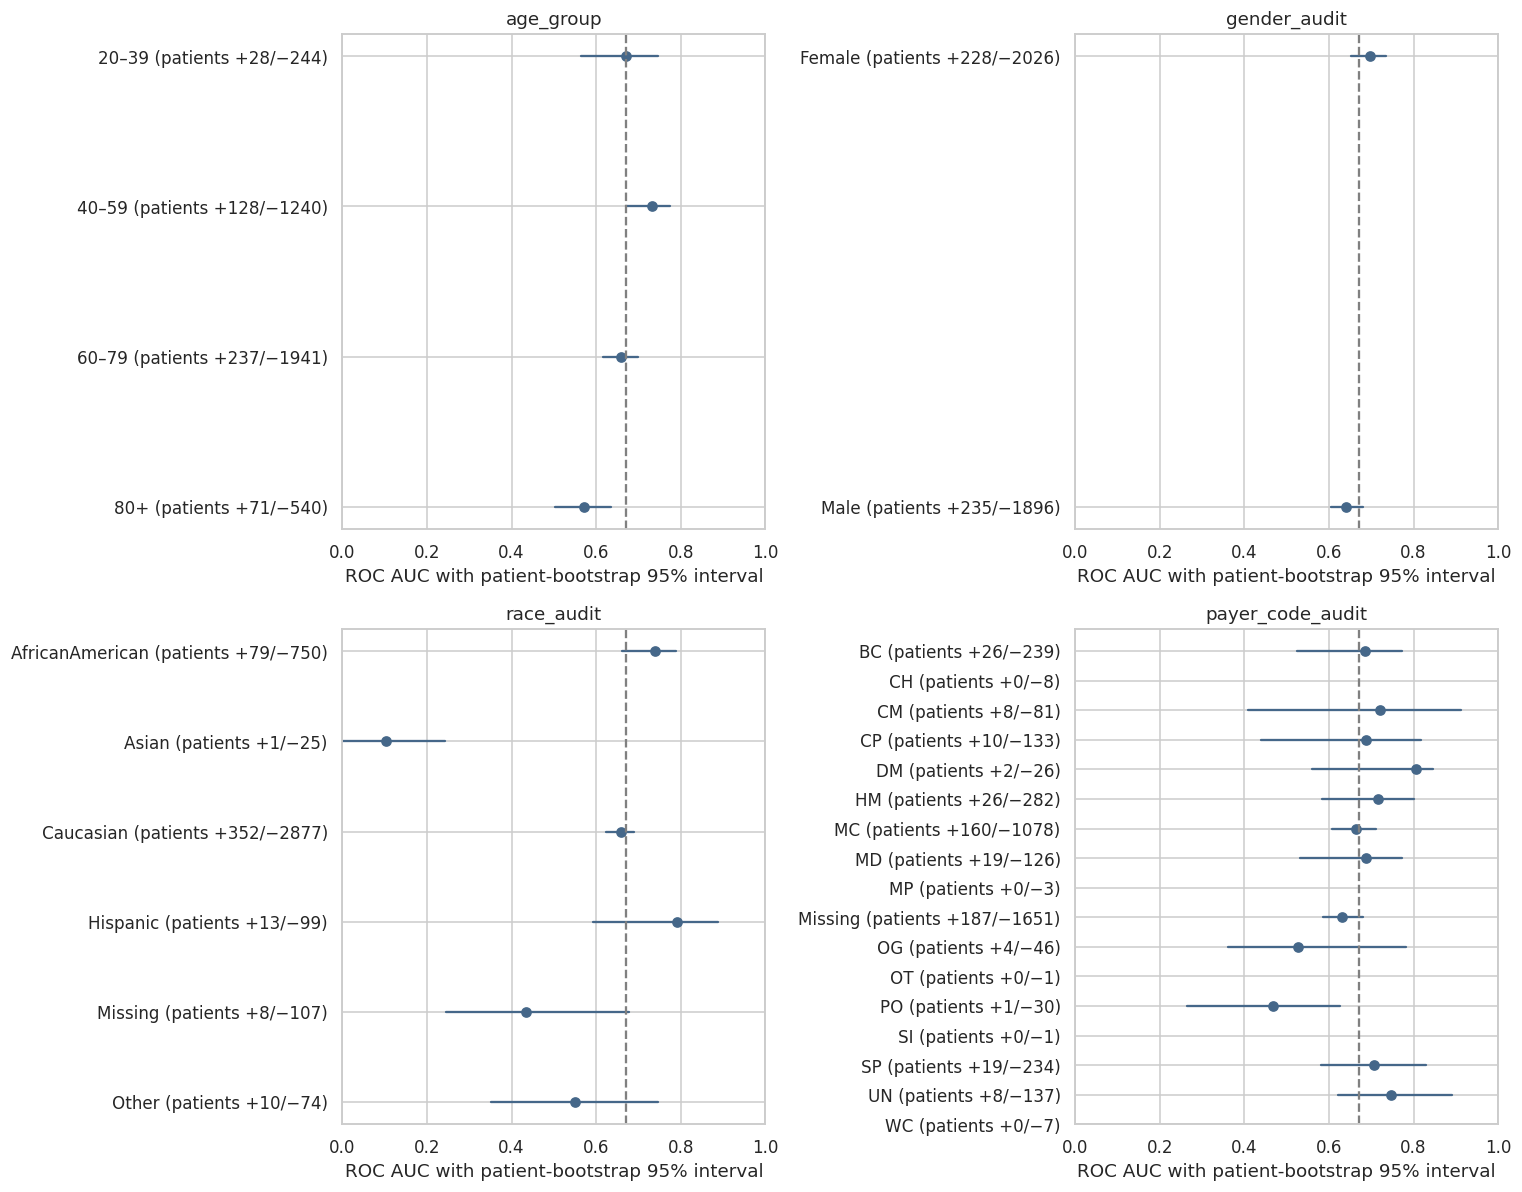

**So what?** On policy validation, logistic regression has AP **0.250** versus prevalence **0.111**, and ROC AUC **0.672** (95% interval **0.638–0.701**). The paired AP difference is **0.139** (95% interval **0.095–0.182**). These are ranking results, not proof of reliable probabilities or a useful contact policy. **17 subgroup rows** have fewer than 20 distinct patients contributing positive or negative encounters and must not support firm disparity claims. No model changes were made in response to these validation results.

,attribute,group,encounters,positives,patients,positive_patients,negative_patients,caution
7,race_audit,Asian,30,1,26,1,25,Small / single-class patient support
9,race_audit,Hispanic,141,21,102,13,99,Small / single-class patient support
10,race_audit,Missing,117,8,112,8,107,Small / single-class patient support
11,race_audit,Other,95,10,81,10,74,Small / single-class patient support
13,payer_code_audit,CH,8,0,8,0,8,Small / single-class patient support
14,payer_code_audit,CM,109,10,83,8,81,Small / single-class patient support
15,payer_code_audit,CP,163,14,138,10,133,Small / single-class patient support
16,payer_code_audit,DM,55,13,27,2,26,Small / single-class patient support
19,payer_code_audit,MD,196,27,131,19,126,Small / single-class patient support
20,payer_code_audit,MP,3,0,3,0,3,Small / single-class patient support


In [8]:
audit_columns = ["age_group", "gender_audit", "race_audit", "payer_code_audit"]
audit = policy_df[[PATIENT_ID, TARGET] + audit_columns].copy()
audit["score"] = p_policy_raw
subgroup_rows = []
for attribute in audit_columns:
    for group, frame in audit.groupby(attribute, dropna=False, sort=True):
        point, low, high, valid = cluster_metric_intervals(frame[TARGET], frame["score"], frame[PATIENT_ID])
        positives = int(frame[TARGET].sum())
        positive_patients = frame.loc[frame[TARGET].eq(1), PATIENT_ID].nunique()
        negative_patients = frame.loc[frame[TARGET].eq(0), PATIENT_ID].nunique()
        subgroup_rows.append({
            "attribute": attribute, "group": group, "encounters": len(frame),
            "patients": frame[PATIENT_ID].nunique(), "positives": positives,
            "positive_patients": positive_patients, "negative_patients": negative_patients,
            "prevalence": frame[TARGET].mean(), "AP": point[0], "AP_low": low[0], "AP_high": high[0],
            "ROC_AUC": point[1], "ROC_low": low[1], "ROC_high": high[1],
            "valid_bootstraps": valid,
            "caution": "Small / single-class patient support" if min(positive_patients, negative_patients) < 20 else "",
        })
subgroup_metrics = pd.DataFrame(subgroup_rows)
display(subgroup_metrics.round(4))
subgroup_metrics.to_csv(ARTIFACT_DIR / "policy_subgroup_discrimination.csv", index=False)
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
overall_auc = metrics_table.loc[metrics_table["model"].eq("Logistic regression"), "ROC_AUC"].iloc[0]
for ax, attribute in zip(axes.ravel(), audit_columns):
    rows = subgroup_metrics.loc[subgroup_metrics["attribute"].eq(attribute)].reset_index(drop=True)
    for i, row in rows.iterrows():
        if pd.notna(row["ROC_AUC"]):
            ax.plot([row["ROC_low"], row["ROC_high"]], [i, i], color="#456789")
            ax.plot(row["ROC_AUC"], i, "o", color="#456789")
    ax.axvline(overall_auc, color="gray", linestyle="--", label="Overall ROC AUC")
    ax.set_yticks(range(len(rows)), [f"{r['group']} (patients +{r['positive_patients']}/−{r['negative_patients']})" for _, r in rows.iterrows()])
    ax.set(xlabel="ROC AUC with patient-bootstrap 95% interval", title=attribute, xlim=(0, 1))
    ax.invert_yaxis()
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "policy_subgroup_auc.png", bbox_inches="tight")
plt.show()

logistic_row = metrics_table.loc[metrics_table["model"].eq("Logistic regression")].iloc[0]
difference_row = metrics_table.loc[metrics_table["model"].eq("Logistic minus baseline")].iloc[0]
small_rows = subgroup_metrics.loc[subgroup_metrics["caution"].ne("")]
display(Markdown(
    f"**So what?** On policy validation, logistic regression has AP **{logistic_row['AP']:.3f}** "
    f"versus prevalence **{y_policy.mean():.3f}**, and ROC AUC **{logistic_row['ROC_AUC']:.3f}** "
    f"(95% interval **{logistic_row['ROC_low']:.3f}–{logistic_row['ROC_high']:.3f}**). "
    f"The paired AP difference is **{difference_row['AP']:.3f}** "
    f"(95% interval **{difference_row['AP_low']:.3f}–{difference_row['AP_high']:.3f}**). "
    "These are ranking results, not proof of reliable probabilities or a useful contact policy. "
    f"**{len(small_rows)} subgroup rows** have fewer than 20 distinct patients contributing positive or negative encounters and must not support firm disparity claims. "
    "No model changes were made in response to these validation results."
))
if len(small_rows):
    display(small_rows[["attribute", "group", "encounters", "positives", "patients",
                        "positive_patients", "negative_patients", "caution"]])


## Group handoff — first half ends here

**Completed inputs in memory:** `train_df`, `calibration_df`, `policy_df`, `test_df`; `X_train/y_train`, `X_cal/y_cal`, `X_policy/y_policy`; `feature_columns`, `numeric_features`, `categorical_features`; fitted uncalibrated `model` and `baseline`; `p_policy_raw`, `p_policy_baseline`; overall/subgroup development tables. `cluster_metric_intervals` supplies patient-cluster intervals for AP/ROC AUC.

**Reproduction:** Run this first half to recreate exact cohort, transformations, and partitions; use the saved manifest to audit assignment. `artifacts/uncalibrated_logistic.joblib` is a convenience model artifact for the same pinned environment. Load joblib files only from trusted sources. The original CSVs are included in `Data/`; generated artifacts remain local/ignored. The notebook includes outputs, and rerunning regenerates the artifacts.

| Group responsibility | Contract |
|---|---|
| Step 6 — calibration | Fit calibration on `X_cal/y_cal` only; keep base model frozen. In sklearn 1.5.1 use the documented prefit calibration API. Evaluate on policy data. |
| Step 7 — thresholds | Select from policy data only; compare workload and recall constraints, including the 200/250 contact scenarios. 85% recall and 40% precision are aspirations, not results. |
| Step 8 — test | Lock full model, calibrator, features and threshold before first test predictions. Do not select a new policy to improve test results. |
| Step 9 — RAI | Test compatibility on development data; set up model/input representation and threshold semantics explicitly. Dashboard libraries are not installed or verified by this first-half run. |
| Presentation | Use saved plots and actual findings; distinguish ranking, calibration, policy impact, and causal claims. |

**Second half:** Sections 6–9 below complete these assignments in order: calibration on the calibration partition, the threshold policy on policy validation, one final-test evaluation after the lock, and the Responsible AI analysis. Helpers live in `utils.py`; the environment now pins the Responsible AI toolbox (`environment.yml`). The cell below records the handoff state and still asserts that no second-half objects exist, which is why the notebook must be run once from a fresh kernel.

In [9]:
handoff = {
    "completed_steps": [1, 2, 3, 4, 5], "remaining_steps": [6, 7, 8, 9],
    "target": TARGET, "positive_label": "readmitted == <30", "prediction_time": "discharge",
    "random_state": RANDOM_STATE, "minimum_age": 20,
    "eligible_discharge_codes": sorted(HOME_OUTPATIENT_CODES),
    "numeric_features": numeric_features, "categorical_features": categorical_features,
    "audit_columns": audit_columns, "test_evaluated": False, "calibration_fitted": False,
    "threshold_selected": False, "data_sha256": actual_hashes,
    "split_manifest_sha256": hashlib.sha256((ARTIFACT_DIR / "split_manifest.csv").read_bytes()).hexdigest(),
    "policy_aspirations": {"recall": RECALL_FLOOR, "precision": PRECISION_ASPIRATION,
                           "contacts_per_1000": [ALERT_BUDGET_PER_1000, ALTERNATIVE_ALERT_BUDGET_PER_1000]},
}
(ARTIFACT_DIR / "handoff.json").write_text(json.dumps(handoff, indent=2) + "\n")
# Contract checks: no calibration, threshold, or final-test predictions have been created.
assert all(name not in globals() for name in ["calibrated_model", "locked_threshold", "p_test", "y_test_pred"])
print("First half complete. Calibration, threshold selection, and final-test evaluation remain unexecuted.")


First half complete. Calibration, threshold selection, and final-test evaluation remain unexecuted.


## 6. Probability calibration and uncertainty — 8%

**Goal:** a score of 0.20 should correspond to roughly a 20% recorded-readmission rate among comparable scored encounters, not a guarantee for an individual. The training model stays frozen; the calibrator is fitted on the calibration partition only and assessed on policy validation. Test data remain untouched.

**Method:** Platt (sigmoid) scaling through `CalibratedClassifierCV(cv="prefit")`, the documented prefit API for the pinned scikit-learn 1.5.1. Metrics: Brier score, log loss, expected calibration error (ECE) over up to ten tie-preserving quantile bins, and calibration-in-the-large (mean predicted probability versus observed prevalence). Equal scores stay together, so ties can produce unequal bin sizes or fewer occupied bins; the constant-prevalence baseline has one bin. The metric column is named `ece_equal_count` for this approximately equal-count strategy. Quantile bins are used because equal-width bins would be almost empty above 0.3 at this prevalence, so this ECE is not directly comparable with equal-width ECE values from the literature. Brier and ECE carry 95% patient-cluster bootstrap intervals (300 replicates, seed 42, undefined replicates dropped, as in Step 5). The prevalence baseline is shown because a constant prediction already reaches a Brier score near 0.099 here; Brier alone is therefore not a pure calibration measure.

In [10]:
from utils import (positive_proba, calibration_metrics, calibration_intervals, reliability_table, patient_bootstrap,
                   threshold_table, pick_policy, subgroup_policy_table, ThresholdedEstimator, PolicyScaleEstimator, error_tree_leaves, leaf_mask)
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(model, method="sigmoid", cv="prefit").fit(X_cal, y_cal)
p_policy = positive_proba(calibrated_model, X_policy)
joblib.dump(calibrated_model, ARTIFACT_DIR / "calibrated_logistic.joblib")
print(f"Calibration partition: {len(y_cal):,} encounters, {int(y_cal.sum()):,} positives, prevalence {y_cal.mean():.2%}")

policy_scores = {"Prevalence baseline": p_policy_baseline, "Raw logistic": p_policy_raw, "Calibrated logistic": p_policy}
calibration_rows = []
for name, scores in policy_scores.items():
    frame = pd.DataFrame({"y": y_policy.to_numpy(), "p": scores, PATIENT_ID: policy_df[PATIENT_ID].to_numpy()})
    row = {"model": name, **calibration_metrics(frame["y"], frame["p"]),
           **calibration_intervals(frame, PATIENT_ID, N_BOOTSTRAP, RANDOM_STATE)}
    row["AP"], row["ROC_AUC"] = discrimination_metrics(frame["y"], frame["p"])
    calibration_rows.append(row)
calibration_table = pd.DataFrame(calibration_rows)
display(calibration_table.round(4))
calibration_table.to_csv(ARTIFACT_DIR / "policy_calibration.csv", index=False)

Calibration partition: 5,422 encounters, 525 positives, prevalence 9.68%


,model,brier,log_loss,ece_equal_count,mean_predicted,observed_prevalence,brier_low,brier_high,valid_bootstraps,ece_equal_count_low,ece_equal_count_high,AP,ROC_AUC
0,Prevalence baseline,0.0988,0.3491,0.0108,0.1002,0.111,0.0903,0.1082,300,0.0009,0.0226,0.111,0.5000
1,Raw logistic,0.0931,0.3266,0.0130,0.1024,0.111,0.0862,0.1008,300,0.0099,0.0243,0.250,0.6715
2,Calibrated logistic,0.0930,0.3266,0.0136,0.0996,0.111,0.0862,0.1008,300,0.0094,0.0243,0.250,0.6715


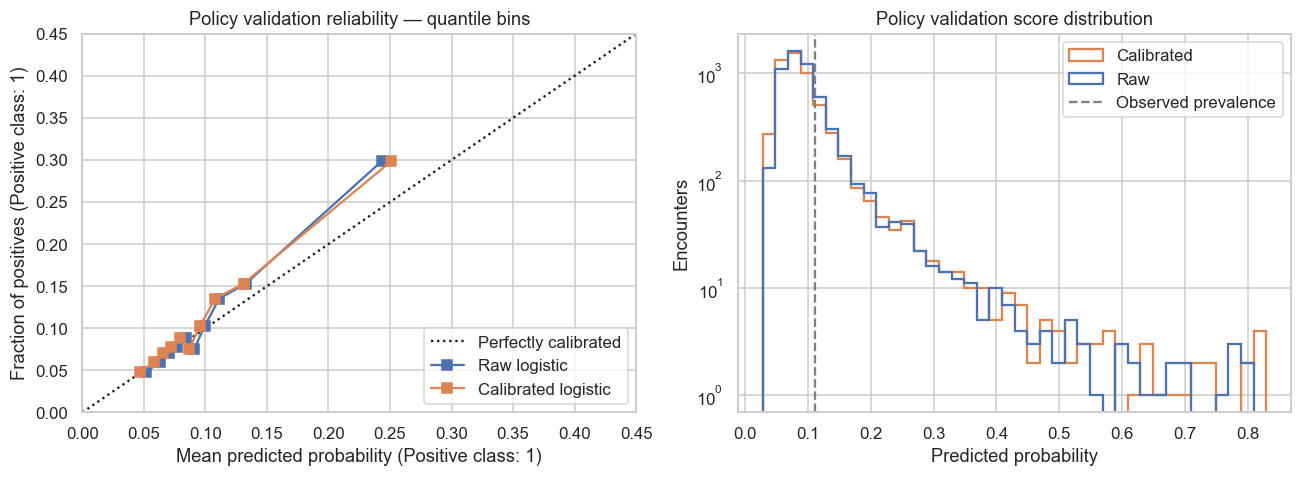

,records,min_predicted,max_predicted,mean_predicted,observed_rate,abs_gap
band,,,,,,
1,556,0.028,0.054,0.047,0.049,0.001
2,555,0.054,0.062,0.059,0.059,0.001
3,555,0.062,0.069,0.066,0.070,0.005
4,555,0.069,0.076,0.072,0.077,0.005
5,555,0.076,0.083,0.080,0.088,0.009
6,555,0.083,0.091,0.087,0.076,0.011
7,555,0.091,0.101,0.096,0.103,0.007
8,555,0.101,0.116,0.108,0.135,0.027
9,555,0.116,0.151,0.131,0.153,0.022


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name in ["Raw logistic", "Calibrated logistic"]:
    CalibrationDisplay.from_predictions(y_policy, policy_scores[name], n_bins=10, strategy="quantile", name=name, ax=axes[0])
axes[0].set(title="Policy validation reliability — quantile bins", xlim=(0, 0.45), ylim=(0, 0.45))
axes[1].hist([p_policy_raw, p_policy], bins=40, histtype="step", linewidth=1.5, label=["Raw", "Calibrated"])
axes[1].axvline(y_policy.mean(), color="gray", linestyle="--", label="Observed prevalence")
axes[1].set(title="Policy validation score distribution", xlabel="Predicted probability", ylabel="Encounters", yscale="log")
axes[1].legend()
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "policy_reliability.png", bbox_inches="tight")
plt.show()

risk_bands = reliability_table(y_policy, p_policy)
display(risk_bands.round(3))
risk_bands.to_csv(ARTIFACT_DIR / "policy_risk_bands.csv")

In [12]:
audit = policy_df[[PATIENT_ID, TARGET] + audit_columns].assign(score=p_policy)
subgroup_calibration = pd.concat([
    audit.groupby(attribute, dropna=False).apply(lambda g: pd.Series({
        "encounters": len(g), "positives": int(g[TARGET].sum()),
        "positive_patients": g.loc[g[TARGET].eq(1), PATIENT_ID].nunique(),
        "negative_patients": g.loc[g[TARGET].eq(0), PATIENT_ID].nunique(),
        "mean_predicted": g["score"].mean(), "observed": g[TARGET].mean(),
        "brier": brier_score_loss(g[TARGET], g["score"]),
    })).rename_axis("group").reset_index().assign(attribute=attribute)
    for attribute in audit_columns
], ignore_index=True).astype({"encounters": int, "positives": int, "positive_patients": int, "negative_patients": int})
subgroup_calibration["observed_to_expected"] = subgroup_calibration["observed"] / subgroup_calibration["mean_predicted"]
subgroup_calibration["caution"] = np.where(
    subgroup_calibration[["positive_patients", "negative_patients"]].min(axis=1) < 20, "Small / single-class patient support", "")
display(subgroup_calibration.round(3))
subgroup_calibration.to_csv(ARTIFACT_DIR / "policy_subgroup_calibration.csv", index=False)

calibrated_row = calibration_table.set_index("model").loc["Calibrated logistic"]
top_band = risk_bands.iloc[-1]
off_groups = subgroup_calibration.query("caution == '' and (observed_to_expected < 0.8 or observed_to_expected > 1.25)")
display(Markdown(
    f"**So what?** On policy validation the calibrated model predicts a mean risk of **{calibrated_row['mean_predicted']:.3f}** "
    f"against an observed rate of **{calibrated_row['observed_prevalence']:.3f}**; Brier **{calibrated_row['brier']:.4f}** "
    f"(95% interval {calibrated_row['brier_low']:.4f}–{calibrated_row['brier_high']:.4f}) versus **{calibration_table['brier'].iloc[0]:.4f}** for the prevalence baseline, "
    f"and quantile-bin ECE **{calibrated_row['ece_equal_count']:.3f}** ({calibrated_row['ece_equal_count_low']:.3f}–{calibrated_row['ece_equal_count_high']:.3f}). "
    f"Ranking is unchanged (AP {calibrated_row['AP']:.3f}, ROC AUC {calibrated_row['ROC_AUC']:.3f}). "
    f"In the highest-risk tenth the model predicts **{top_band['mean_predicted']:.3f}** while **{top_band['observed_rate']:.3f}** were readmitted, so the scores most relevant to a contact policy underestimate risk. "
    f"**{len(off_groups)}** adequately supported subgroups have an observed-to-expected ratio outside 0.8–1.25"
    + (": " + ", ".join(f"{r.group} ({r.observed_to_expected:.2f})" for r in off_groups.itertuples()) if len(off_groups) else "") + "."
))
handoff.update(calibration_fitted=True)
(ARTIFACT_DIR / "handoff.json").write_text(json.dumps(handoff, indent=2) + "\n");

,group,encounters,positives,positive_patients,negative_patients,mean_predicted,observed,brier,attribute,observed_to_expected,caution
0,20–39,345,42,28,244,0.109,0.122,0.102,age_group,1.119,
1,40–59,1754,203,128,1240,0.097,0.116,0.093,age_group,1.190,
2,60–79,2698,290,237,1941,0.097,0.107,0.091,age_group,1.113,
3,80+,755,81,71,540,0.111,0.107,0.096,age_group,0.963,
4,Female,2879,330,228,2026,0.102,0.115,0.094,gender_audit,1.129,
5,Male,2673,286,235,1896,0.097,0.107,0.092,gender_audit,1.097,
6,AfricanAmerican,1111,127,79,750,0.112,0.114,0.091,race_audit,1.024,
7,Asian,30,1,1,25,0.078,0.033,0.037,race_audit,0.429,Small / single-class patient support
8,Caucasian,4058,449,352,2877,0.099,0.111,0.094,race_audit,1.121,
9,Hispanic,141,21,13,99,0.075,0.149,0.119,race_audit,1.978,Small / single-class patient support


**So what?** On policy validation the calibrated model predicts a mean risk of **0.100** against an observed rate of **0.111**; Brier **0.0930** (95% interval 0.0862–0.1008) versus **0.0988** for the prevalence baseline, and quantile-bin ECE **0.014** (0.009–0.024). Ranking is unchanged (AP 0.250, ROC AUC 0.672). In the highest-risk tenth the model predicts **0.251** while **0.299** were readmitted, so the scores most relevant to a contact policy underestimate risk. **0** adequately supported subgroups have an observed-to-expected ratio outside 0.8–1.25.

**Interpretation.** Platt scaling is a sigmoid fitted to a logistic model's logits, so it can only shift and stretch scores that are already on a probability scale; the small change seen here is expected, and it is not evidence that calibration was unnecessary. The calibrated mean sits slightly below the observed rate because the calibration partition happened to contain fewer readmissions (9.7%) than policy validation (11.1%): these are patient-disjoint samples of the same source, not stratified splits. The practical consequence is that the probabilities are usable for population-level workload planning (how many of the contacted patients are expected to be readmitted), while the highest-risk band underestimates risk and no individual score is a guarantee. Better calibration says nothing about whether contacting a patient prevents readmission; that requires an intervention study.

## 7. Threshold selection and decision analysis — 8%

A threshold turns a calibrated probability into a follow-up contact. Everything in this section uses **policy validation only**; model and calibrator are frozen and test data are not scored.

**Candidates and rule:** every distinct calibrated score plus 0 (contact everyone) and infinity (contact nobody), with the rule *contact if score ≥ threshold*. Among equally good thresholds the higher one (fewer contacts) is chosen, so the selection is deterministic.

**Analyses compared**

1. **Workload-constrained:** most readmissions contacted within the primary budget of 200 contacts per 1,000 discharges (`ALERT_BUDGET_PER_1000`); the 250 scenario (`ALTERNATIVE_ALERT_BUDGET_PER_1000`) is reported as a sensitivity. The primary budget is the one Step 1 named as primary, fixed before any result was seen.
2. **Recall floor:** highest precision among thresholds that contact at least 85% of recorded readmissions.
3. **Illustrative harm weights:** one missed readmission counted as 2, 5 or 10 unnecessary contacts; classroom weights, not measured utilities or costs.

**Prespecified decision rule:** choose the threshold that satisfies both the primary budget and the recall floor with the highest precision. If no threshold satisfies both, keep the primary budget, because contact capacity is the constraint a discharge team cannot exceed, and report the recall and precision actually reached and which aspiration was dropped. The default 0.50 cutoff is shown for reference only. Staff time assumes **20 minutes per contact** (one call plus documentation), an assumption to replace with local data. Every count below is per 1,000 eligible discharges and describes contacts and case finding, not readmissions prevented.

In [13]:
MINUTES_PER_CONTACT = 20  # assumption: one follow-up call plus documentation per contacted discharge
candidate_table = threshold_table(y_policy, p_policy, MINUTES_PER_CONTACT)
candidate_table.to_csv(ARTIFACT_DIR / "policy_threshold_table.csv", index=False)
print(f"{len(candidate_table):,} candidate thresholds: 0, every distinct calibrated score, and inf (contact nobody)")

PRIMARY_WORKLOAD = f"Workload ≤ {ALERT_BUDGET_PER_1000}/1,000 (primary budget)"
RECALL_POLICY = f"Recall ≥ {RECALL_FLOOR:.0%}, highest precision"
policies = {
    "Default 0.50 cutoff (reference)": threshold_table(y_policy, p_policy, MINUTES_PER_CONTACT, [0.5]).iloc[0],
    PRIMARY_WORKLOAD: pick_policy(candidate_table, "recall", ALERT_BUDGET_PER_1000),
    f"Workload ≤ {ALTERNATIVE_ALERT_BUDGET_PER_1000}/1,000 (alternative)": pick_policy(candidate_table, "recall", ALTERNATIVE_ALERT_BUDGET_PER_1000),
    RECALL_POLICY: pick_policy(candidate_table, "precision", recall_floor=RECALL_FLOOR),
}
for ratio in [2, 5, 10]:
    harm = candidate_table["fp"] + ratio * candidate_table["fn"]
    policies[f"Harm {ratio}:1 (missed : unnecessary), lowest total harm"] = (
        candidate_table.assign(harm=harm).sort_values(["harm", "threshold"], ascending=[True, False]).iloc[0])
policy_table = pd.DataFrame([{"policy": name, **row.to_dict()} for name, row in policies.items()])
display(policy_table.drop(columns="harm").round(3))
policy_table.to_csv(ARTIFACT_DIR / "policy_candidates.csv", index=False)

5,554 candidate thresholds: 0, every distinct calibrated score, and inf (contact nobody)


,policy,threshold,tp,fp,fn,tn,precision,recall,specificity,alerts_per_1000,false_alerts_per_1000,missed_per_1000,staff_hours_per_1000
0,Default 0.50 cutoff (reference),0.500,19.0,13.0,597.0,4923.0,0.594,0.031,0.997,5.764,2.341,107.529,1.921
1,"Workload ≤ 200/1,000 (primary budget)",0.116,251.0,856.0,365.0,4080.0,0.227,0.407,0.827,199.388,154.179,65.742,66.463
2,"Workload ≤ 250/1,000 (alternative)",0.108,289.0,1096.0,327.0,3840.0,0.209,0.469,0.778,249.460,197.406,58.898,83.153
3,"Recall ≥ 85%, highest precision",0.067,528.0,3504.0,88.0,1432.0,0.131,0.857,0.290,726.225,631.124,15.850,242.075
4,"Harm 2:1 (missed : unnecessary), lowest total ...",0.262,78.0,86.0,538.0,4850.0,0.476,0.127,0.983,29.539,15.490,96.902,9.846
5,"Harm 5:1 (missed : unnecessary), lowest total ...",0.140,190.0,478.0,426.0,4458.0,0.284,0.308,0.903,120.317,86.095,76.729,40.106
6,"Harm 10:1 (missed : unnecessary), lowest total...",0.087,406.0,2048.0,210.0,2888.0,0.165,0.659,0.585,442.003,368.876,37.824,147.334


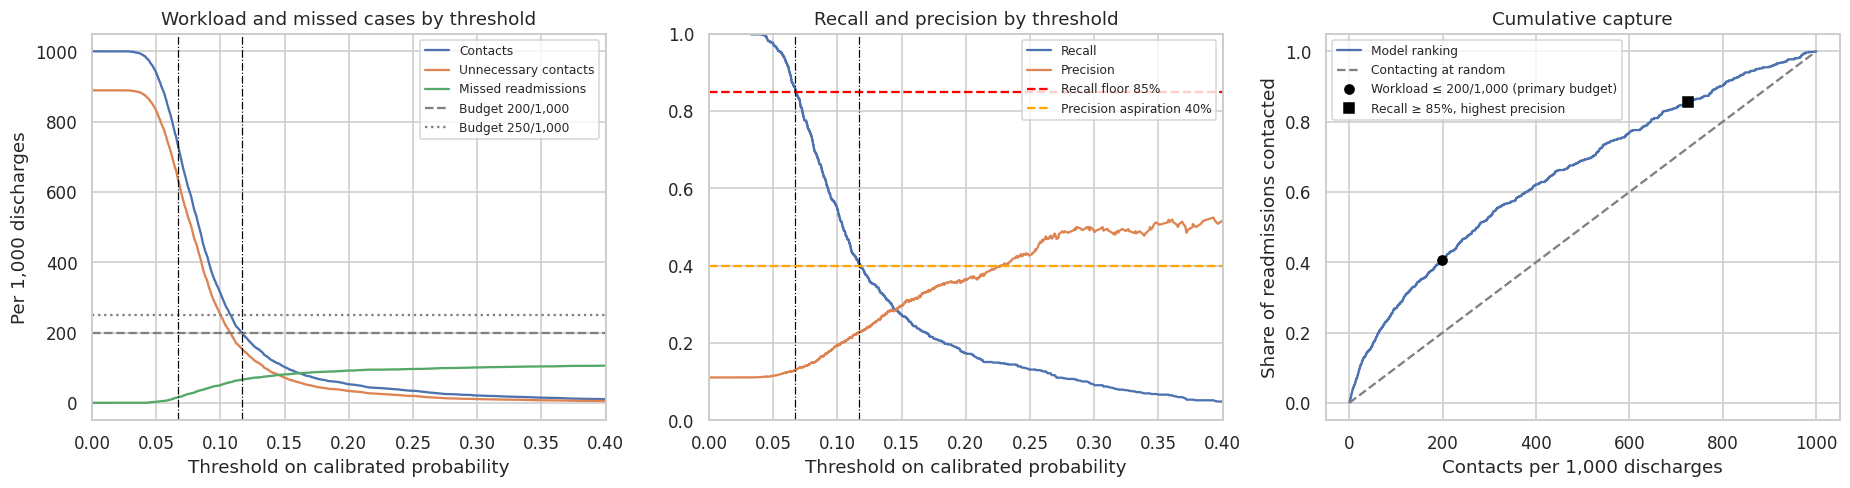

In [14]:
finite = candidate_table[np.isfinite(candidate_table["threshold"])]
compared = {PRIMARY_WORKLOAD: "o", RECALL_POLICY: "s"}
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
for column, label in [("alerts_per_1000", "Contacts"), ("false_alerts_per_1000", "Unnecessary contacts"),
                      ("missed_per_1000", "Missed readmissions")]:
    axes[0].plot(finite["threshold"], finite[column], label=label)
for budget, style in [(ALERT_BUDGET_PER_1000, "--"), (ALTERNATIVE_ALERT_BUDGET_PER_1000, ":")]:
    axes[0].axhline(budget, color="gray", linestyle=style, label=f"Budget {budget}/1,000")
axes[0].set(xlim=(0, 0.4), xlabel="Threshold on calibrated probability", ylabel="Per 1,000 discharges",
            title="Workload and missed cases by threshold")
axes[1].plot(finite["threshold"], finite["recall"], label="Recall")
axes[1].plot(finite["threshold"], finite["precision"], label="Precision")
axes[1].axhline(RECALL_FLOOR, color="red", linestyle="--", label=f"Recall floor {RECALL_FLOOR:.0%}")
axes[1].axhline(PRECISION_ASPIRATION, color="orange", linestyle="--", label=f"Precision aspiration {PRECISION_ASPIRATION:.0%}")
axes[1].set(xlim=(0, 0.4), ylim=(0, 1), xlabel="Threshold on calibrated probability", title="Recall and precision by threshold")
axes[2].plot(finite["alerts_per_1000"], finite["recall"], label="Model ranking")
axes[2].plot([0, 1000], [0, 1], color="gray", linestyle="--", label="Contacting at random")
axes[2].set(xlabel="Contacts per 1,000 discharges", ylabel="Share of readmissions contacted", title="Cumulative capture")
for name, marker in compared.items():
    row = policies[name]
    for ax in axes[:2]:
        ax.axvline(row["threshold"], color="black", linestyle="-.", linewidth=0.8)
    axes[2].plot(row["alerts_per_1000"], row["recall"], marker, color="black", label=name)
for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "policy_threshold_tradeoffs.png", bbox_inches="tight")
plt.show()

In [15]:
frame = pd.DataFrame({"y": y_policy.to_numpy(), "p": p_policy, PATIENT_ID: policy_df[PATIENT_ID].to_numpy()})
uncertainty_rows = []
for name in compared:
    threshold = policies[name]["threshold"]
    for metric in ["recall", "precision", "alerts_per_1000"]:
        point, low, high, valid = patient_bootstrap(
            lambda f: threshold_table(f["y"], f["p"], MINUTES_PER_CONTACT, [threshold])[metric].iloc[0],
            frame, PATIENT_ID, N_BOOTSTRAP, RANDOM_STATE)
        uncertainty_rows.append({"policy": name, "threshold": threshold, "metric": metric,
                                 "point": point, "low": low, "high": high, "valid_bootstraps": valid})
policy_uncertainty = pd.DataFrame(uncertainty_rows)
display(policy_uncertainty.round(3))
policy_uncertainty.to_csv(ARTIFACT_DIR / "policy_uncertainty.csv", index=False)

joint = pick_policy(candidate_table, "precision", ALERT_BUDGET_PER_1000, RECALL_FLOOR)
if joint is not None:
    chosen, rule = joint, f"recall >= {RECALL_FLOOR} within {ALERT_BUDGET_PER_1000}/1,000, highest precision"
else:
    chosen, rule = policies[PRIMARY_WORKLOAD], f"joint rule infeasible; primary budget {ALERT_BUDGET_PER_1000}/1,000 kept, highest recall"
    recall_row = policies[RECALL_POLICY]
    print(f"No threshold reaches {RECALL_FLOOR:.0%} recall within {ALERT_BUDGET_PER_1000} contacts per 1,000: "
          f"the recall floor alone needs {recall_row['alerts_per_1000']:.0f} contacts per 1,000 at precision {recall_row['precision']:.2f}. "
          f"The recall aspiration is dropped; the budget is kept.")
locked_threshold = float(chosen["threshold"])
policy_lock = {
    "threshold": locked_threshold, "rule": rule, "selection_data": "policy validation only",
    "calibrator": "sigmoid, prefit on the calibration partition", "features": feature_columns,
    "minutes_per_contact": MINUTES_PER_CONTACT, "split_manifest_sha256": handoff["split_manifest_sha256"],
    "policy_validation": {k: float(chosen[k]) for k in ["recall", "precision", "alerts_per_1000", "false_alerts_per_1000",
                                                          "missed_per_1000", "staff_hours_per_1000"]},
}
(ARTIFACT_DIR / "policy_lock.json").write_text(json.dumps(policy_lock, indent=2) + "\n")
handoff.update(threshold_selected=True, locked_threshold=locked_threshold)
(ARTIFACT_DIR / "handoff.json").write_text(json.dumps(handoff, indent=2) + "\n");
print(f"Locked threshold: {locked_threshold:.4f} ({rule}). Test data have not been scored.")

display(Markdown(
    f"**So what?** Per 1,000 eligible discharges at the locked threshold, the team makes **{chosen['alerts_per_1000']:.0f} contacts** "
    f"(about **{chosen['staff_hours_per_1000']:.0f} staff hours** at {MINUTES_PER_CONTACT} minutes each): "
    f"**{1000 * chosen['tp'] / len(y_policy):.0f}** reach patients later readmitted, **{chosen['false_alerts_per_1000']:.0f}** are unnecessary, "
    f"and **{chosen['missed_per_1000']:.0f}** readmissions are missed (recall {chosen['recall']:.2f}, precision {chosen['precision']:.2f}). "
    f"Reaching the {RECALL_FLOOR:.0%} recall aspiration instead would take **{policies[RECALL_POLICY]['alerts_per_1000']:.0f} contacts** per 1,000 "
    f"at precision {policies[RECALL_POLICY]['precision']:.2f}, so the {PRECISION_ASPIRATION:.0%} precision and {RECALL_FLOOR:.0%} recall aspirations cannot hold together with this model. "
    f"At the default 0.50 cutoff only **{policies['Default 0.50 cutoff (reference)']['alerts_per_1000']:.0f}** contacts per 1,000 would be made: "
    "the low event rate makes the default cutoff nearly useless, which is why the threshold is a policy choice rather than a model property."
))

,policy,threshold,metric,point,low,high,valid_bootstraps
0,"Workload ≤ 200/1,000 (primary budget)",0.116,recall,0.407,0.348,0.462,300
1,"Workload ≤ 200/1,000 (primary budget)",0.116,precision,0.227,0.189,0.264,300
2,"Workload ≤ 200/1,000 (primary budget)",0.116,alerts_per_1000,199.388,182.061,216.641,300
3,"Recall ≥ 85%, highest precision",0.067,recall,0.857,0.825,0.885,300
4,"Recall ≥ 85%, highest precision",0.067,precision,0.131,0.116,0.147,300
5,"Recall ≥ 85%, highest precision",0.067,alerts_per_1000,726.225,712.978,739.045,300


No threshold reaches 85% recall within 200 contacts per 1,000: the recall floor alone needs 726 contacts per 1,000 at precision 0.13. The recall aspiration is dropped; the budget is kept.
Locked threshold: 0.1165 (joint rule infeasible; primary budget 200/1,000 kept, highest recall). Test data have not been scored.


**So what?** Per 1,000 eligible discharges at the locked threshold, the team makes **199 contacts** (about **66 staff hours** at 20 minutes each): **45** reach patients later readmitted, **154** are unnecessary, and **66** readmissions are missed (recall 0.41, precision 0.23). Reaching the 85% recall aspiration instead would take **726 contacts** per 1,000 at precision 0.13, so the 40% precision and 85% recall aspirations cannot hold together with this model. At the default 0.50 cutoff only **6** contacts per 1,000 would be made: the low event rate makes the default cutoff nearly useless, which is why the threshold is a policy choice rather than a model property.

**Interpretation.** The three analyses agree on the shape of the trade-off: the model concentrates readmissions in its top ranks, but not sharply enough for both aspirations to hold. Within the primary budget the discharge team contacts roughly one in five patients and reaches about four in ten of the readmissions, with about one contact in four concerning a patient who is later readmitted. The recall floor is reachable only by contacting most discharges, which is no longer prioritisation. The harm-weight sensitivity shows that the budget policy corresponds to valuing a missed readmission at somewhere between five and ten unnecessary contacts; a team that values it more highly should ask for more capacity or a better model rather than a lower threshold. None of these counts is a readmission prevented: they describe who would be contacted and who would be missed.

## 8. Final test evaluation and generalization — 4%

**Gate:** model, preprocessing, calibrator, feature set, threshold and subgroup definitions are locked in `artifacts/policy_lock.json`. The checks below verify that the notebook state matches that lock and that no test predictions exist yet; they cannot detect a lock that was moved and re-saved. The actual guarantee is procedural: test rows are read for the first time in the next cell, and the notebook is run once from a fresh kernel. Nothing in this section feeds back into the model or the threshold.

**Report:** AP, ROC AUC, Brier and tie-preserving quantile-bin ECE with patient-cluster intervals, a reliability plot, the confusion matrix and per-1,000 impact at the locked threshold compared with the policy-validation expectations, and the prespecified subgroup checks at the locked threshold.

Final test: 10,864 encounters from 8,197 patients, 1,031 recorded early readmissions (9.49%). Labels opened once, after the lock.


,AP,AP_low,AP_high,ROC_AUC,ROC_low,ROC_high,brier,log_loss,ece_equal_count,mean_predicted,observed_prevalence,brier_low,brier_high,valid_bootstraps,ece_equal_count_low,ece_equal_count_high
final_test,0.1795,0.1569,0.2035,0.6471,0.6272,0.6686,0.0834,0.3009,0.0071,0.0954,0.0949,0.079,0.0881,300.0,0.0058,0.0143


,policy_validation,final_test,test_low,test_high
alerts_per_1000,199.388,182.345,171.195,194.443
recall,0.407,0.357,0.319,0.396
precision,0.227,0.186,0.166,0.208
false_alerts_per_1000,154.179,148.472,NaN,NaN
missed_per_1000,65.742,61.027,NaN,NaN
staff_hours_per_1000,66.463,60.782,NaN,NaN


Confusion matrix at the locked threshold (rows: recorded outcome 0/1; columns: contact 0/1):
[[8220 1613]
 [ 663  368]]


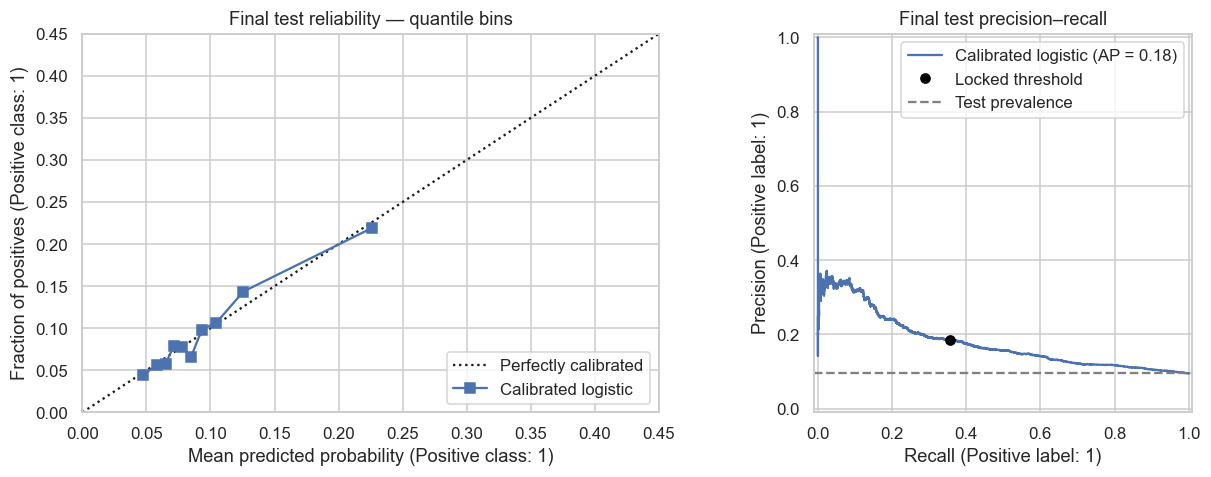

In [16]:
policy_lock = json.loads((ARTIFACT_DIR / "policy_lock.json").read_text())
assert np.isclose(policy_lock["threshold"], locked_threshold) and policy_lock["features"] == feature_columns
assert handoff["calibration_fitted"] and handoff["threshold_selected"] and not handoff["test_evaluated"]
assert "p_test" not in globals(), "Test predictions must not exist before this cell; restart the kernel and run all."
X_test, y_test = test_df[feature_columns], test_df[TARGET]
p_test = positive_proba(calibrated_model, X_test)
y_test_pred = (p_test >= locked_threshold).astype(int)
print(f"Final test: {len(y_test):,} encounters from {test_df[PATIENT_ID].nunique():,} patients, "
      f"{int(y_test.sum()):,} recorded early readmissions ({y_test.mean():.2%}). Labels opened once, after the lock.")

test_frame = pd.DataFrame({"y": y_test.to_numpy(), "p": p_test, PATIENT_ID: test_df[PATIENT_ID].to_numpy()})
point, low, high, valid = cluster_metric_intervals(y_test, p_test, test_df[PATIENT_ID])
test_metrics = pd.Series({"AP": point[0], "AP_low": low[0], "AP_high": high[0], "ROC_AUC": point[1], "ROC_low": low[1], "ROC_high": high[1],
                          **calibration_metrics(y_test, p_test),
                          **calibration_intervals(test_frame, PATIENT_ID, N_BOOTSTRAP, RANDOM_STATE)}, name="final_test")
display(test_metrics.to_frame().T.round(4))
test_metrics.to_json(ARTIFACT_DIR / "test_metrics.json", indent=2)

impact = threshold_table(y_test, p_test, MINUTES_PER_CONTACT, [locked_threshold]).iloc[0]
comparison = pd.DataFrame({"policy_validation": policy_lock["policy_validation"]}).reindex(
    ["alerts_per_1000", "recall", "precision", "false_alerts_per_1000", "missed_per_1000", "staff_hours_per_1000"])
comparison["final_test"] = impact[comparison.index]
for metric in ["recall", "precision", "alerts_per_1000"]:
    _, comparison.loc[metric, "test_low"], comparison.loc[metric, "test_high"], _ = patient_bootstrap(
        lambda f: threshold_table(f["y"], f["p"], MINUTES_PER_CONTACT, [locked_threshold])[metric].iloc[0],
        test_frame, PATIENT_ID, N_BOOTSTRAP, RANDOM_STATE)
display(comparison.round(3))
comparison.to_csv(ARTIFACT_DIR / "test_policy_impact.csv")
print("Confusion matrix at the locked threshold (rows: recorded outcome 0/1; columns: contact 0/1):")
print(confusion_matrix(y_test, y_test_pred, labels=[0, 1]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
CalibrationDisplay.from_predictions(y_test, p_test, n_bins=10, strategy="quantile", name="Calibrated logistic", ax=axes[0])
axes[0].set(title="Final test reliability — quantile bins", xlim=(0, 0.45), ylim=(0, 0.45))
PrecisionRecallDisplay.from_predictions(y_test, p_test, name="Calibrated logistic", ax=axes[1])
axes[1].plot(impact["recall"], impact["precision"], "o", color="black", label="Locked threshold")
axes[1].axhline(y_test.mean(), color="gray", linestyle="--", label="Test prevalence")
axes[1].set(title="Final test precision–recall")
axes[1].legend()
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "test_reliability_pr.png", bbox_inches="tight")
plt.show()

,attribute,group,encounters,patients,positives,positive_patients,negative_patients,selection_rate,recall,fnr,fpr,precision,mean_predicted,observed,caution,recall_low,recall_high,valid_bootstraps
0,age_group,20–39,684,497,90,61,481,0.209,0.511,0.489,0.163,0.322,0.103,0.132,,0.382,0.617,300.0
1,age_group,40–59,3535,2665,314,240,2600,0.139,0.309,0.691,0.123,0.197,0.085,0.089,,0.237,0.387,300.0
2,age_group,60–79,5150,3968,455,385,3831,0.181,0.345,0.655,0.165,0.169,0.096,0.088,,0.292,0.392,300.0
3,age_group,80+,1495,1159,172,143,1088,0.278,0.395,0.605,0.263,0.163,0.115,0.115,,0.296,0.472,300.0
4,gender_audit,Female,5627,4250,516,418,4117,0.174,0.343,0.657,0.157,0.181,0.094,0.092,,0.280,0.395,300.0
5,gender_audit,Male,5237,3947,515,409,3794,0.191,0.371,0.629,0.172,0.191,0.097,0.098,,0.324,0.413,300.0
6,race_audit,AfricanAmerican,2156,1580,210,170,1537,0.194,0.429,0.571,0.169,0.215,0.097,0.097,,0.357,0.501,300.0
7,race_audit,Asian,69,65,5,5,60,0.043,0.000,1.000,0.047,0.000,0.072,0.072,Small / single-class patient support,0.000,0.000,298.0
8,race_audit,Caucasian,7954,6016,753,600,5787,0.188,0.353,0.647,0.171,0.178,0.097,0.095,,0.306,0.395,300.0
9,race_audit,Hispanic,238,181,27,22,176,0.071,0.111,0.889,0.066,0.176,0.065,0.113,,0.000,0.255,300.0


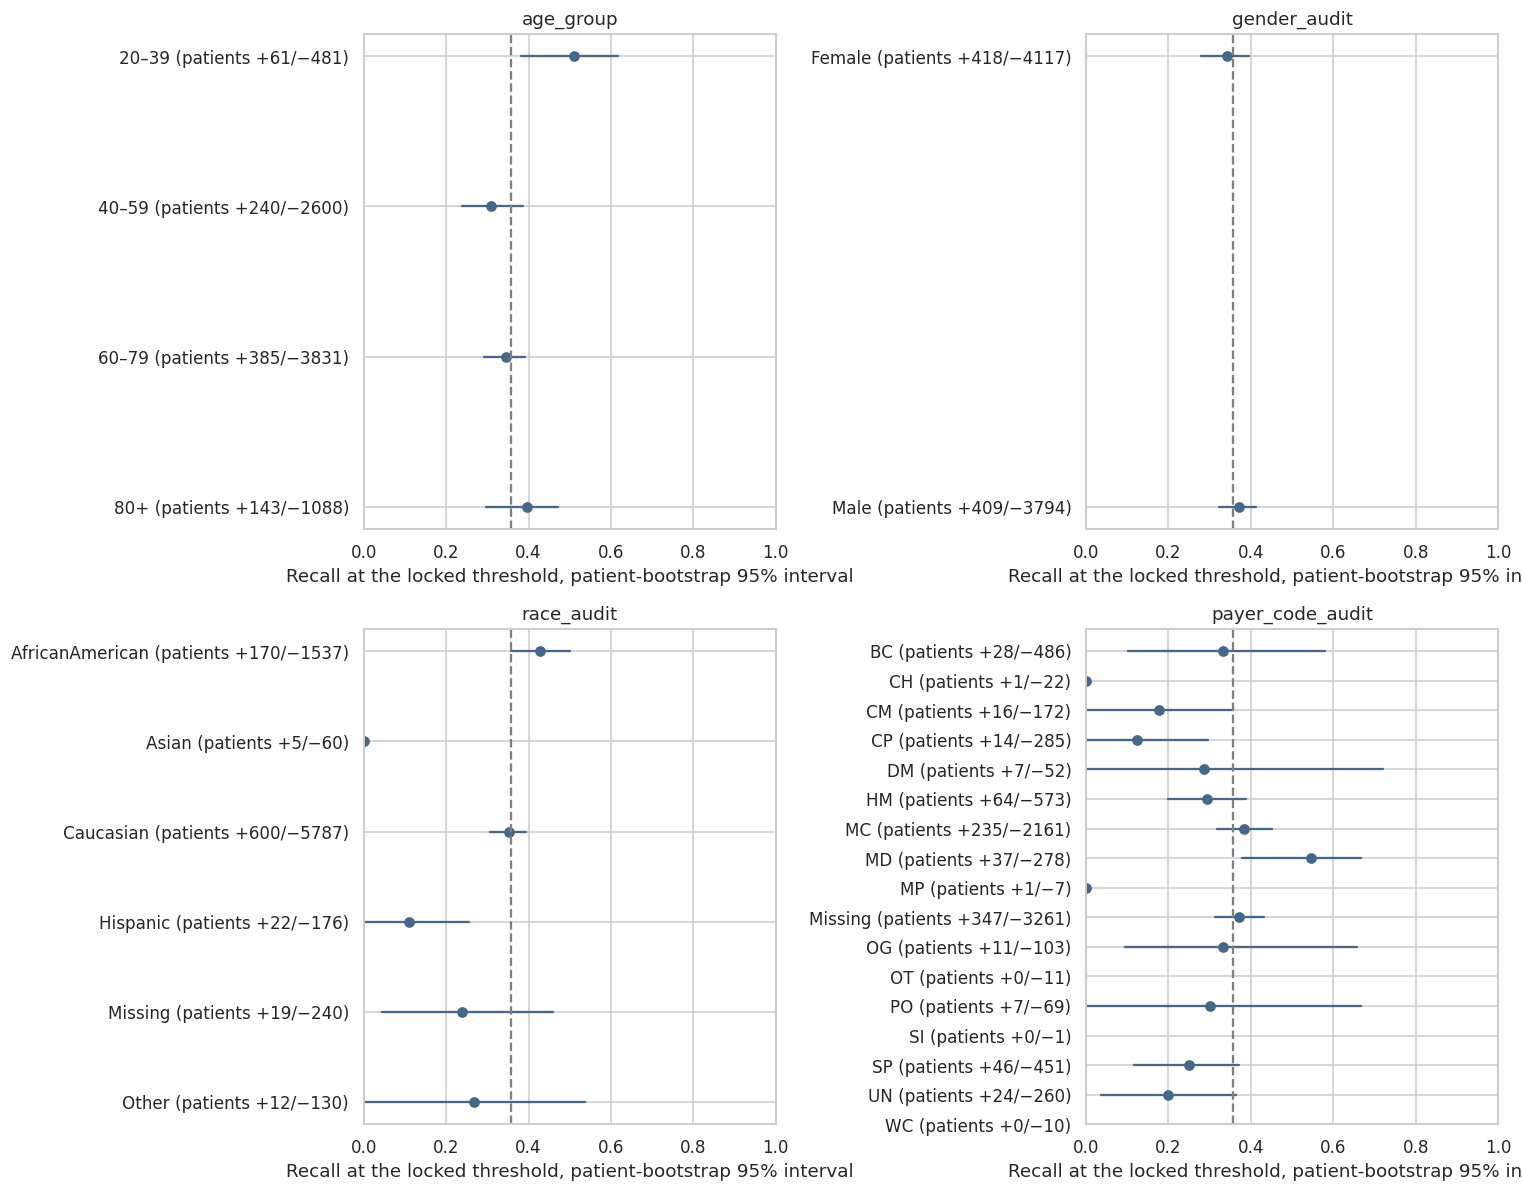

**So what?** On held-out patients the locked policy makes **182 contacts per 1,000** (budget 200, policy validation 199), reaches recall **0.36** (95% interval 0.32–0.40; policy validation 0.41) and precision **0.19** (0.17–0.21; policy validation 0.23). Per 1,000 discharges that is **34** contacts to patients later readmitted, **148** unnecessary contacts and **61** missed readmissions. Test prevalence is 9.5% against 11.1% on policy validation, which lowers AP to **0.179** (1.89× prevalence; policy validation 2.25×) with ROC AUC **0.647** (0.627–0.669). Among adequately supported age, gender and race groups, missed readmissions are most frequent for **Hispanic** (FNR 0.89) and unnecessary contacts for **80+** (FPR 0.26); **13** subgroup rows have too few patients for any disparity claim. The threshold was not changed in response to these results.

In [17]:
test_audit = test_df[[PATIENT_ID, TARGET] + audit_columns].assign(score=p_test)
test_subgroups = subgroup_policy_table(test_audit, audit_columns, "score", TARGET, PATIENT_ID, locked_threshold)
recall_at_lock = lambda f: f.loc[f[TARGET].eq(1), "score"].ge(locked_threshold).mean()
test_subgroups[["recall_low", "recall_high", "valid_bootstraps"]] = [
    patient_bootstrap(recall_at_lock, part, PATIENT_ID, N_BOOTSTRAP, RANDOM_STATE)[1:]
    for attribute in audit_columns for _, part in test_audit.groupby(attribute, dropna=False, sort=True)]
display(test_subgroups.round(3))
test_subgroups.to_csv(ARTIFACT_DIR / "test_subgroup_policy.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, attribute in zip(axes.ravel(), audit_columns):
    rows = test_subgroups.loc[test_subgroups["attribute"].eq(attribute)].reset_index(drop=True)
    for i, row in rows.iterrows():
        if pd.notna(row["recall"]):
            ax.plot([row["recall_low"], row["recall_high"]], [i, i], color="#456789")
            ax.plot(row["recall"], i, "o", color="#456789")
    ax.axvline(impact["recall"], color="gray", linestyle="--", label="Overall test recall")
    ax.set_yticks(range(len(rows)), [f"{r['group']} (patients +{r['positive_patients']}/−{r['negative_patients']})" for _, r in rows.iterrows()])
    ax.set(xlabel="Recall at the locked threshold, patient-bootstrap 95% interval", title=attribute, xlim=(0, 1))
    ax.invert_yaxis()
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "test_subgroup_recall.png", bbox_inches="tight")
plt.show()

supported = test_subgroups.loc[test_subgroups["caution"].eq("") & test_subgroups["attribute"].ne("payer_code_audit")]
most_missed = supported.sort_values("fnr").iloc[-1]
most_contacted = supported.sort_values("fpr").iloc[-1]
handoff.update(test_evaluated=True)
(ARTIFACT_DIR / "handoff.json").write_text(json.dumps(handoff, indent=2) + "\n");
expected = policy_lock["policy_validation"]
display(Markdown(
    f"**So what?** On held-out patients the locked policy makes **{impact['alerts_per_1000']:.0f} contacts per 1,000** "
    f"(budget {ALERT_BUDGET_PER_1000}, policy validation {expected['alerts_per_1000']:.0f}), reaches recall **{impact['recall']:.2f}** "
    f"(95% interval {comparison.loc['recall', 'test_low']:.2f}–{comparison.loc['recall', 'test_high']:.2f}; policy validation {expected['recall']:.2f}) "
    f"and precision **{impact['precision']:.2f}** ({comparison.loc['precision', 'test_low']:.2f}–{comparison.loc['precision', 'test_high']:.2f}; policy validation {expected['precision']:.2f}). "
    f"Per 1,000 discharges that is **{1000 * impact['tp'] / len(y_test):.0f}** contacts to patients later readmitted, **{impact['false_alerts_per_1000']:.0f}** unnecessary contacts "
    f"and **{impact['missed_per_1000']:.0f}** missed readmissions. Test prevalence is {y_test.mean():.1%} against {y_policy.mean():.1%} on policy validation, "
    f"which lowers AP to **{test_metrics['AP']:.3f}** ({test_metrics['AP'] / y_test.mean():.2f}× prevalence; policy validation {logistic_row['AP'] / y_policy.mean():.2f}×) "
    f"with ROC AUC **{test_metrics['ROC_AUC']:.3f}** ({test_metrics['ROC_low']:.3f}–{test_metrics['ROC_high']:.3f}). "
    f"Among adequately supported age, gender and race groups, missed readmissions are most frequent for **{most_missed['group']}** "
    f"(FNR {most_missed['fnr']:.2f}) and unnecessary contacts for **{most_contacted['group']}** (FPR {most_contacted['fpr']:.2f}); "
    f"**{int(test_subgroups['caution'].ne('').sum())}** subgroup rows have too few patients for any disparity claim. "
    "The threshold was not changed in response to these results."
))

**Generalization.** The workload stayed within budget on held-out patients, but recall and precision came in somewhat below the policy-validation values, and the test intervals do not contain them: the policy-validation numbers were chosen to be the best among thousands of candidates on one sample, so some shrinkage on new patients is expected, and the lower test prevalence lowers precision and AP mechanically. This is the only generalization the design can show: same institutions, same 1999–2008 period, same warehouse. What it cannot show: performance on today's discharge practices and coding, on hospitals outside the warehouse, or on readmissions to other systems, which the label never captures. Age bands, absent social information and no timestamps for a temporal split all remain. Before a prospective pilot the team would need a temporal or external validation, a local estimate of minutes per contact and of capacity, a definition of the follow-up bundle, and an evaluation design that measures whether contacts change outcomes, which this retrospective analysis does not.

## 9. Responsible AI analysis — RAI Toolbox — 30%

`RAIInsights` computes explanations, an error-analysis tree, counterfactuals and a causal analysis for the **locked** calibrated model, and `ResponsibleAIDashboard` renders them interactively. Policy validation is the exploration set; final-test findings above stay descriptive and nothing here feeds back into the model or threshold.

**Input contract.** The dashboard frames hold the 17 model features plus the target, in their clinically readable form (bands, codes, categories), so cohorts and explanations are stated in chart terms rather than one-hot columns. The dashboard managers reject missing values, so the 2% of encounters with unrecorded race receive the training-fitted mode, exactly what the pipeline's imputer does internally; the cell checks that calibrated probabilities are unchanged. A seeded sample of 10,000 training encounters is used as the reference set (the counterfactual and causal components scale poorly and the library caps the eval set at 5,000 rows by default) together with 2,000 policy-validation encounters; every table in 9.1 and 9.2 is nevertheless computed on the full partitions.

**Threshold semantics.** The calibrated classifier's default `predict` would use 0.50, which contacts almost nobody at this prevalence. The model is therefore wrapped so that `predict` applies the locked threshold, and the dashboard's error, fairness and counterfactual views describe the selected policy. Computed insights are saved to `artifacts/rai_insights` and can be reloaded with `RAIInsights.load` without recomputing.

In [18]:
import random
import shutil
from responsibleai import RAIInsights
from responsibleai.feature_metadata import FeatureMetadata
from raiwidgets import ResponsibleAIDashboard

RAI_TRAIN_ROWS, RAI_EVAL_ROWS = 10_000, 2_000
impute = model.named_steps["preprocess"].named_transformers_["categorical"].named_steps["impute"]
fill_values = dict(zip(categorical_features, impute.statistics_))
def rai_frame(frame):
    return frame[feature_columns].fillna(fill_values).assign(**{TARGET: frame[TARGET].to_numpy()})
rai_train = rai_frame(train_df.sample(n=RAI_TRAIN_ROWS, random_state=RANDOM_STATE))
rai_eval = rai_frame(policy_df.sample(n=RAI_EVAL_ROWS, random_state=RANDOM_STATE))
covered = np.logical_and.reduce([rai_eval[c].isin(rai_train[c].unique()) for c in categorical_features])
rai_eval = rai_eval[covered]
assert np.allclose(positive_proba(calibrated_model, rai_eval[feature_columns]),
                   positive_proba(calibrated_model, policy_df.loc[rai_eval.index, feature_columns]))
rai_model = ThresholdedEstimator(calibrated_model, locked_threshold)
print(f"RAI frames: {len(rai_train):,} training and {len(rai_eval):,} policy-validation encounters "
      f"({int((~covered).sum())} dropped for categories absent from the training sample). "
      f"Dashboard contact rate at the locked threshold: {rai_model.predict(rai_eval[feature_columns]).mean():.3f}")

ACTIONABLE = ["A1Cresult", "insulin", "change", "diabetesMed"]   # testing and treatment recorded during the stay
PROBE = ["number_inpatient", "number_diagnoses", "num_medications"]   # history and encounter totals: not actionable, a model probe only
rai = RAIInsights(model=rai_model, train=rai_train, test=rai_eval, target_column=TARGET, task_type="classification",
                  feature_metadata=FeatureMetadata(categorical_features=categorical_features))
rai.explainer.add()
rai.error_analysis.add()
rai.counterfactual.add(total_CFs=5, method="random", desired_class="opposite", features_to_vary=ACTIONABLE,
                       permitted_range={c: sorted(rai_train[c].unique()) for c in ACTIONABLE}, feature_importance=False)
rai.counterfactual.add(total_CFs=5, method="random", desired_class="opposite", features_to_vary=PROBE,
                       permitted_range={c: [int(rai_train[c].min()), int(rai_train[c].max())] for c in PROBE}, feature_importance=False)
CAUSAL_HETEROGENEITY = ["number_inpatient"]   # age bands as heterogeneity make the final-stage design rank-deficient
causal_categories = lambda categoricals: [["None", "Norm", ">7", ">8"] if c == "A1Cresult" else "auto" for c in categoricals]
rai.causal.add(treatment_features=["A1Cresult"], heterogeneity_features=CAUSAL_HETEROGENEITY,
               categories=causal_categories(categorical_features), random_state=RANDOM_STATE)
random.seed(RANDOM_STATE); np.random.seed(RANDOM_STATE)   # DiCE's random search is otherwise unseeded
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="A column-vector y")
    rai.compute()
shutil.rmtree(ARTIFACT_DIR / "rai_insights", ignore_errors=True)
rai.save(str(ARTIFACT_DIR / "rai_insights"))

RAI frames: 10,000 training and 1,999 policy-validation encounters (1 dropped for categories absent from the training sample). Dashboard contact rate at the locked threshold: 0.198
Causal Effects
Current Status: Generating Causal Effects.


A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().


A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().


A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().


A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().


...

100%|██████████| 1999/1999 [02:29<00:00, 13.38it/s]

Current Status: Generated 5 counterfactuals for 1999 samples.
Time taken: 4.0 min 27.02191084200058 sec


Error Analysis
Current Status: Generating error analysis reports.
Current Status: Finished generating error analysis reports.
Time taken: 0.0 min 0.1395648199995776 sec
Explanations
Current Status: Explaining 17 features


categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.


Current Status: Explained 17 features.
Time taken: 0.0 min 1.2796980519997305 sec


In [19]:
ResponsibleAIDashboard(rai)

ResponsibleAI started at http://localhost:8704


### 9.1 Data analysis and cohort exploration

Three cohorts were fixed before looking at results, from the hypotheses in the handoff: prior inpatient use (`number_inpatient >= 1`), no HbA1c test recorded during the stay (`A1Cresult == "None"`), and age 80+ (`age` in `[80-90)` or `[90-100)`). The table describes each cohort on training data and reports how the locked policy behaves for it on policy validation. In the dashboard the same cohorts are created with the **Cohort settings** filter on the eval set; the Data analysis view then shows their feature and outcome distributions.

In [20]:
cohort_rules = {
    "Prior inpatient use": lambda f: f["number_inpatient"].ge(1),
    "No HbA1c test recorded": lambda f: f["A1Cresult"].eq("None"),
    "Age 80+": lambda f: f["age"].isin(["[80-90)", "[90-100)"]),
    "All eligible encounters": lambda f: pd.Series(True, index=f.index),
}
policy_scored = policy_df.assign(score=p_policy)
cohort_rows = []
for name, rule in cohort_rules.items():
    train_part, policy_part = train_df[rule(train_df)], policy_scored[rule(policy_scored)]
    policy_impact = threshold_table(policy_part[TARGET], policy_part["score"], MINUTES_PER_CONTACT, [locked_threshold]).iloc[0]
    cohort_rows.append({
        "cohort": name, "train_encounters": len(train_part), "train_share": len(train_part) / len(train_df),
        "train_prevalence": train_part[TARGET].mean(), "no_hba1c_share": train_part["A1Cresult"].eq("None").mean(),
        "mean_prior_inpatient": train_part["number_inpatient"].mean(), "mean_medications": train_part["num_medications"].mean(),
        "race_missing_share": train_part["race"].isna().mean(),
        "policy_encounters": len(policy_part), "policy_prevalence": policy_part[TARGET].mean(),
        "policy_contact_rate": policy_impact["alerts_per_1000"] / 1000, "policy_recall": policy_impact["recall"],
        "policy_precision": policy_impact["precision"],
    })
cohort_table = pd.DataFrame(cohort_rows)
display(cohort_table.round(3))
cohort_table.to_csv(ARTIFACT_DIR / "rai_cohorts.csv", index=False)
prior, untested, oldest, everyone = (cohort_table.set_index("cohort").loc[n] for n in cohort_rules)
display(Markdown(
    f"**So what?** Patients with a prior inpatient stay are **{prior['train_share']:.0%}** of training encounters but have a readmission rate of "
    f"**{prior['train_prevalence']:.1%}** versus **{everyone['train_prevalence']:.1%}** overall, and the policy contacts **{prior['policy_contact_rate']:.0%}** of them "
    f"(recall {prior['policy_recall']:.2f}, precision {prior['policy_precision']:.2f}): prior utilisation is where the model finds most of its signal. "
    f"HbA1c was not measured in **{untested['train_share']:.0%}** of stays; that cohort's readmission rate (**{untested['train_prevalence']:.1%}**) is close to the overall rate, "
    f"so absence of a test is a marker of practice more than of risk. Patients aged 80+ are contacted at **{oldest['policy_contact_rate']:.0%}** "
    f"with precision **{oldest['policy_precision']:.2f}**, the lowest of the three cohorts, consistent with the weaker ranking seen for this group in Step 5."
))

,cohort,train_encounters,train_share,train_prevalence,no_hba1c_share,mean_prior_inpatient,mean_medications,race_missing_share,policy_encounters,policy_prevalence,policy_contact_rate,policy_recall,policy_precision
0,Prior inpatient use,16503,0.322,0.160,0.869,1.915,16.366,0.013,1831,0.180,0.561,0.733,0.236
1,No HbA1c test recorded,42419,0.828,0.103,1.000,0.654,15.448,0.022,4622,0.110,0.218,0.437,0.220
2,Age 80+,7308,0.143,0.112,0.863,0.584,14.213,0.021,755,0.107,0.305,0.432,0.152
3,All eligible encounters,51253,1.000,0.100,0.828,0.617,15.564,0.023,5552,0.111,0.199,0.407,0.227


**So what?** Patients with a prior inpatient stay are **32%** of training encounters but have a readmission rate of **16.0%** versus **10.0%** overall, and the policy contacts **56%** of them (recall 0.73, precision 0.24): prior utilisation is where the model finds most of its signal. HbA1c was not measured in **83%** of stays; that cohort's readmission rate (**10.3%**) is close to the overall rate, so absence of a test is a marker of practice more than of risk. Patients aged 80+ are contacted at **30%** with precision **0.15**, the lowest of the three cohorts, consistent with the weaker ranking seen for this group in Step 5.

### 9.2 Model overview and fairness

The dashboard's **Model overview** view reports accuracy, precision, recall, false-positive and false-negative rates and selection rate per feature-based cohort at the locked threshold, because the wrapped model's `predict` applies that threshold. The table below is the same comparison on the full policy-validation partition, with denominators, distinct-patient counts and calibration (observed-to-expected ratio), for recorded race, gender and age group. Payer is audited in Section 8 and omitted here because most payer groups have too few patients.

In [21]:
fairness_columns = ["age_group", "gender_audit", "race_audit"]
policy_audit = policy_df[[PATIENT_ID, TARGET] + fairness_columns].assign(score=p_policy)
policy_fairness = subgroup_policy_table(policy_audit, fairness_columns, "score", TARGET, PATIENT_ID, locked_threshold)
policy_fairness["observed_to_expected"] = policy_fairness["observed"] / policy_fairness["mean_predicted"]
display(policy_fairness.round(3))
policy_fairness.to_csv(ARTIFACT_DIR / "rai_policy_fairness.csv", index=False)

supported = policy_fairness.loc[policy_fairness["caution"].eq("")]
spread = supported.groupby("attribute").agg(recall_min=("recall", "min"), recall_max=("recall", "max"),
                                             selection_min=("selection_rate", "min"), selection_max=("selection_rate", "max"))
display(spread.round(3))
by_fnr, by_sel = supported.sort_values("fnr").iloc[-1], supported.sort_values("selection_rate").iloc[-1]
display(Markdown(
    f"**So what?** At the locked threshold, recall ranges from **{spread['recall_min'].min():.2f}** to **{spread['recall_max'].max():.2f}** across adequately supported groups, "
    f"so the burden of missed readmissions is not shared equally: it is highest for **{by_fnr['group']}** (FNR {by_fnr['fnr']:.2f}). "
    f"Unnecessary contacts fall most on **{by_sel['group']}** (selection rate {by_sel['selection_rate']:.2f}, FPR {by_sel['fpr']:.2f}), "
    "because the model assigns higher scores to older and previously hospitalised patients. Calibration ratios stay near 1 for the large groups, "
    "which means the differences are in ranking and base rates rather than in systematically wrong probabilities. "
    "Smaller race groups (Asian, Hispanic, Other, missing race) cannot support disparity claims either way, and missing race itself may reflect data-collection practice. "
    "Per-group thresholds would equalise one metric at the cost of another and would need ethical and legal review before use; they are not applied here."
))

,attribute,group,encounters,patients,positives,positive_patients,negative_patients,selection_rate,recall,fnr,fpr,precision,mean_predicted,observed,caution,observed_to_expected
0,age_group,20–39,345,250,42,28,244,0.214,0.405,0.595,0.188,0.230,0.109,0.122,,1.119
1,age_group,40–59,1754,1272,203,128,1240,0.166,0.429,0.571,0.132,0.298,0.097,0.116,,1.190
2,age_group,60–79,2698,2047,290,237,1941,0.189,0.386,0.614,0.166,0.219,0.097,0.107,,1.113
3,age_group,80+,755,575,81,71,540,0.305,0.432,0.568,0.289,0.152,0.111,0.107,,0.963
4,gender_audit,Female,2879,2104,330,228,2026,0.200,0.448,0.552,0.168,0.256,0.102,0.115,,1.129
5,gender_audit,Male,2673,1995,286,235,1896,0.198,0.360,0.640,0.179,0.194,0.097,0.107,,1.097
6,race_audit,AfricanAmerican,1111,769,127,79,750,0.242,0.512,0.488,0.207,0.242,0.112,0.114,,1.024
7,race_audit,Asian,30,26,1,1,25,0.100,0.000,1.000,0.103,0.000,0.078,0.033,Small / single-class patient support,0.429
8,race_audit,Caucasian,4058,3020,449,352,2877,0.199,0.392,0.608,0.175,0.218,0.099,0.111,,1.121
9,race_audit,Hispanic,141,102,21,13,99,0.106,0.381,0.619,0.058,0.533,0.075,0.149,Small / single-class patient support,1.978


,recall_min,recall_max,selection_min,selection_max
attribute,,,,
age_group,0.386,0.432,0.166,0.305
gender_audit,0.360,0.448,0.198,0.200
race_audit,0.392,0.512,0.199,0.242


**So what?** At the locked threshold, recall ranges from **0.36** to **0.51** across adequately supported groups, so the burden of missed readmissions is not shared equally: it is highest for **Male** (FNR 0.64). Unnecessary contacts fall most on **80+** (selection rate 0.30, FPR 0.29), because the model assigns higher scores to older and previously hospitalised patients. Calibration ratios stay near 1 for the large groups, which means the differences are in ranking and base rates rather than in systematically wrong probabilities. Smaller race groups (Asian, Hispanic, Other, missing race) cannot support disparity claims either way, and missing race itself may reflect data-collection practice. Per-group thresholds would equalise one metric at the cost of another and would need ethical and legal review before use; they are not applied here.

### 9.3 Error analysis

The dashboard's **Error analysis** tree and heatmap split the eval set into cohorts by misclassification rate at the locked threshold (a misclassification is either an unnecessary contact or a missed readmission). The table below lists every leaf of the computed tree with its exact rule; the highest-error leaf is then inspected on the eval set to separate missed readmissions from unnecessary contacts. The age 80+ hypothesis from Step 5 is checked in the same way.

In [22]:
leaves = error_tree_leaves(rai.error_analysis.get()[0].tree)
display(leaves.round(3))
leaves.to_csv(ARTIFACT_DIR / "rai_error_tree_leaves.csv", index=False)

eval_scored = rai_eval.assign(score=positive_proba(calibrated_model, rai_eval[feature_columns]))
eval_scored["contact"] = eval_scored["score"] >= locked_threshold
def error_profile(part, name):
    y, contact = part[TARGET].to_numpy(), part["contact"].to_numpy()
    return {"cohort": name, "encounters": len(part), "prevalence": y.mean(), "contact_rate": contact.mean(),
            "missed_readmissions": int((~contact & (y == 1)).sum()), "unnecessary_contacts": int((contact & (y == 0)).sum()),
            "fnr": (~contact & (y == 1)).sum() / max((y == 1).sum(), 1), "fpr": (contact & (y == 0)).sum() / max((y == 0).sum(), 1)}
worst = leaves.loc[leaves["encounters"].ge(30)].iloc[0]
error_cohorts = pd.DataFrame([
    error_profile(eval_scored[leaf_mask(eval_scored, worst["rule"])], f"Highest-error leaf: {worst['rule']}"),
    error_profile(eval_scored[eval_scored["age"].isin(["[80-90)", "[90-100)"])], "Age 80+"),
    error_profile(eval_scored, "All eval encounters"),
])
display(error_cohorts.round(3))
error_cohorts.to_csv(ARTIFACT_DIR / "rai_error_cohorts.csv", index=False)
leaf, oldest, everyone = error_cohorts.iloc[0], error_cohorts.iloc[1], error_cohorts.iloc[2]
display(Markdown(
    f"**So what?** The highest-error leaf with at least 30 encounters is **{worst['rule']}** ({leaf['encounters']} encounters, "
    f"error rate {worst['error_rate']:.2f} versus {everyone['fpr'] * (1 - everyone['prevalence']) + everyone['fnr'] * everyone['prevalence']:.2f} overall): "
    f"its errors are **{leaf['unnecessary_contacts']} unnecessary contacts** and **{leaf['missed_readmissions']} missed readmissions**, "
    f"so this is a cohort the model over-flags rather than one it misses. Patients aged 80+ show contact rate **{oldest['contact_rate']:.2f}** with FNR "
    f"**{oldest['fnr']:.2f}** and FPR **{oldest['fpr']:.2f}** (overall {everyone['fnr']:.2f} and {everyone['fpr']:.2f}). "
    "A plausible explanation is that utilisation counts and age carry the model, so frequently hospitalised or very old patients are flagged regardless of the reason for the index stay, "
    "which the released data do not describe. Targeted review of flagged patients in this cohort, and adding the primary diagnosis group, are the natural next steps; "
    "these cohorts are exploratory and their counts are small."
))

,rule,encounters,errors,error_rate
0,number_inpatient > 0.00 and number_inpatient >...,267,178,0.667
1,number_inpatient > 0.00 and number_inpatient <...,217,100,0.461
2,number_inpatient > 0.00 and number_inpatient >...,25,11,0.440
3,number_inpatient <= 0.00 and number_diagnoses ...,132,36,0.273
4,number_inpatient > 0.00 and number_inpatient <...,145,26,0.179
5,number_inpatient <= 0.00 and number_diagnoses ...,432,49,0.113
6,number_inpatient <= 0.00 and number_diagnoses ...,625,46,0.074
7,number_inpatient <= 0.00 and number_diagnoses ...,156,3,0.019


,cohort,encounters,prevalence,contact_rate,missed_readmissions,unnecessary_contacts,fnr,fpr
0,Highest-error leaf: number_inpatient > 0.00 an...,267,0.255,0.861,8,170,0.118,0.854
1,Age 80+,264,0.102,0.345,16,80,0.593,0.338
2,All eval encounters,1999,0.111,0.198,138,311,0.622,0.175


**So what?** The highest-error leaf with at least 30 encounters is **number_inpatient > 0.00 and number_inpatient > 1.50 and number_inpatient <= 6.50** (267 encounters, error rate 0.67 versus 0.22 overall): its errors are **170 unnecessary contacts** and **8 missed readmissions**, so this is a cohort the model over-flags rather than one it misses. Patients aged 80+ show contact rate **0.34** with FNR **0.59** and FPR **0.34** (overall 0.62 and 0.18). A plausible explanation is that utilisation counts and age carry the model, so frequently hospitalised or very old patients are flagged regardless of the reason for the index stay, which the released data do not describe. Targeted review of flagged patients in this cohort, and adding the primary diagnosis group, are the natural next steps; these cohorts are exploratory and their counts are small.

### 9.4 Feature importance

The dashboard's **Feature importance** view shows the mimic-explainer importances for the wrapped calibrated model, globally and per encounter. Because the base model is logistic regression, the exact learned weights are also available: the odds-ratio table below is the model's own account of each input. Two encounters, one correctly contacted readmission and one missed readmission, are explained locally.

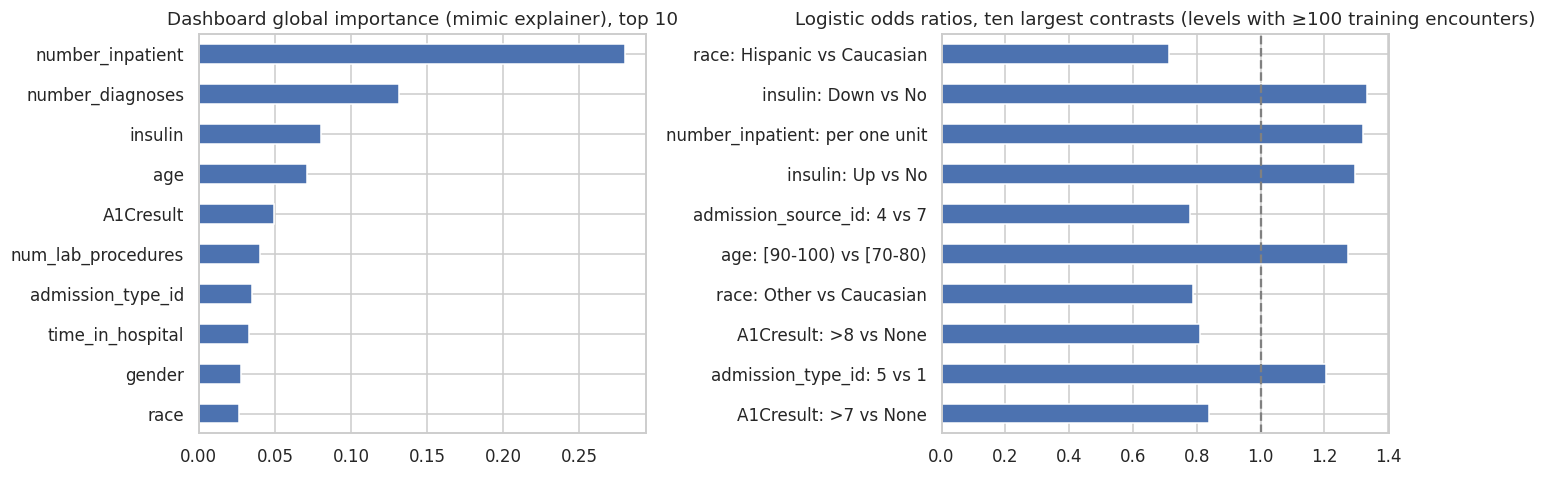

,feature,contrast,log_odds,odds_ratio
0,race,Hispanic vs Caucasian,-0.339,0.712
1,insulin,Down vs No,0.289,1.335
2,number_inpatient,per one unit,0.278,1.321
3,insulin,Up vs No,0.260,1.296
4,admission_source_id,4 vs 7,-0.251,0.778
5,age,[90-100) vs [70-80),0.242,1.274
6,race,Other vs Caucasian,-0.237,0.789
7,A1Cresult,>8 vs None,-0.212,0.809
8,admission_type_id,5 vs 1,0.187,1.206
9,A1Cresult,>7 vs None,-0.178,0.837


Correctly contacted readmission: calibrated risk 0.829, contact=True; number_inpatient=13 (+3.047), age=[40-50) (-0.128), number_diagnoses=9 (+0.083), time_in_hospital=11 (+0.073), insulin=No (-0.066)
Missed readmission: calibrated risk 0.045, contact=False; number_diagnoses=4 (-0.230), number_inpatient=0 (-0.201), age=[50-60) (-0.102), insulin=No (-0.082), admission_type_id=3 (-0.057)


**So what?** Both views agree: **number_inpatient** dominates, followed by **number_diagnoses** and **insulin**; the odds ratios show each additional prior inpatient visit multiplies the odds of recorded readmission by about **1.32**, and the largest categorical contrast is **race: Hispanic vs Caucasian** (odds ratio 0.71). These are the inputs a discharge team can read in the chart at discharge, so the model relies on information clinicians already use, but utilisation counts blend illness burden, access and local admission practice, and the model cannot separate them. The missed readmission above had a low score because its chart showed none of these signals: the model cannot flag what the record does not contain. Importance explains the prediction, not a cause.

In [23]:
explanation = rai.explainer.get()[0]
global_importance = pd.Series(explanation.get_feature_importance_dict()).sort_values(ascending=False)
preprocess = model.named_steps["preprocess"]
encoded = pd.Series(model.named_steps["classifier"].coef_.ravel(), index=[n.split("__", 1)[1] for n in preprocess.get_feature_names_out()])
odds_rows = [{"feature": name, "contrast": "per one unit", "log_odds": encoded[name] / scale}
             for name, scale in zip(numeric_features, preprocess.named_transformers_["numeric"].named_steps["scale"].scale_)]
for name in categorical_features:   # full one-hot encoding: only differences between levels are identifiable
    reference, support = f"{name}_{fill_values[name]}", train_df[name].value_counts()
    odds_rows += [{"feature": name, "contrast": f"{level[len(name) + 1:]} vs {fill_values[name]}", "log_odds": coefficient - encoded[reference]}
                  for level, coefficient in encoded.items()
                  if level.startswith(name + "_") and level != reference and support.get(level[len(name) + 1:], 0) >= 100]
odds_table = pd.DataFrame(odds_rows).assign(odds_ratio=lambda t: np.exp(t["log_odds"]))
odds_table = odds_table.iloc[odds_table["log_odds"].abs().argsort()[::-1]].reset_index(drop=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
global_importance.head(10)[::-1].plot.barh(ax=axes[0], title="Dashboard global importance (mimic explainer), top 10")
odds_table.head(10).set_index(odds_table.head(10)["feature"] + ": " + odds_table.head(10)["contrast"])["odds_ratio"][::-1].plot.barh(
    ax=axes[1], title="Logistic odds ratios, ten largest contrasts (levels with ≥100 training encounters)")
axes[1].axvline(1, color="gray", linestyle="--")
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "rai_feature_importance.png", bbox_inches="tight")
plt.show()
top_contrast = odds_table.loc[odds_table["contrast"].ne("per one unit")].iloc[0]
display(odds_table.head(12).round(3))
odds_table.to_csv(ARTIFACT_DIR / "rai_odds_ratios.csv", index=False)

local_values = np.asarray(explanation.local_importance_values)[list(explanation.classes).index(1)]
positives = eval_scored.reset_index(drop=True).query(f"{TARGET} == 1")
examples = {"Correctly contacted readmission": positives["score"].idxmax(), "Missed readmission": positives["score"].idxmin()}
for label, position in examples.items():
    encounter = eval_scored.iloc[position]
    top = pd.Series(local_values[position], index=explanation.features).sort_values(key=np.abs, ascending=False).head(5)
    print(f"{label}: calibrated risk {encounter['score']:.3f}, contact={bool(encounter['contact'])}; "
          + ", ".join(f"{f}={encounter[f]} ({v:+.3f})" for f, v in top.items()))
display(Markdown(
    f"**So what?** Both views agree: **{global_importance.index[0]}** dominates, followed by **{global_importance.index[1]}** and **{global_importance.index[2]}**; "
    f"the odds ratios show each additional prior inpatient visit multiplies the odds of recorded readmission by about **{odds_table.set_index('feature').loc['number_inpatient', 'odds_ratio']:.2f}**, "
    f"and the largest categorical contrast is **{top_contrast['feature']}: {top_contrast['contrast']}** (odds ratio {top_contrast['odds_ratio']:.2f}). "
    "These are the inputs a discharge team can read in the chart at discharge, so the model relies on information clinicians already use, "
    "but utilisation counts blend illness burden, access and local admission practice, and the model cannot separate them. "
    "The missed readmission above had a low score because its chart showed none of these signals: the model cannot flag what the record does not contain. "
    "Importance explains the prediction, not a cause."
))

### 9.5 Counterfactual analysis

Two counterfactual configurations were computed with DiCE (`method="random"`, up to five counterfactuals per encounter, target class opposite to the current prediction). The **actionable** configuration may vary only the testing and treatment fields recorded during the stay (`A1Cresult`, `insulin`, `change`, `diabetesMed`) within their observed categories; race, gender, age, admission context, encounter totals and prior-year utilisation are held fixed, because a discharge team cannot change them and recorded history must not be "edited" to lower a score. The **probe** configuration varies prior inpatient visits, diagnosis count and medication count to show what the model responds to; it is a description of model behaviour, not recourse. DiCE decides which class an encounter is in from `predict_proba` with a 0.50 rule, so the wrapper's `predict` does not reach it and the dashboard's counterfactuals describe the default cutoff; the first table below measures that mismatch. To obtain counterfactuals for the selected policy, the same two configurations are recomputed against a copy of the model whose probability scale is stretched monotonically so that the locked threshold sits at 0.50 (ranking unchanged), which makes "crossing the contact line" the target.

In [24]:
cf_configurations = {"Actionable at discharge": ACTIONABLE, "Model probe (not actionable)": PROBE}
rai_policy_cf = RAIInsights(model=PolicyScaleEstimator(calibrated_model, locked_threshold), train=rai_train, test=rai_eval,
                            target_column=TARGET, task_type="classification",
                            feature_metadata=FeatureMetadata(categorical_features=categorical_features))
rai_policy_cf.counterfactual.add(total_CFs=5, method="random", desired_class="opposite", features_to_vary=ACTIONABLE,
                                 permitted_range={c: sorted(rai_train[c].unique()) for c in ACTIONABLE}, feature_importance=False)
rai_policy_cf.counterfactual.add(total_CFs=5, method="random", desired_class="opposite", features_to_vary=PROBE,
                                 permitted_range={c: [int(rai_train[c].min()), int(rai_train[c].max())] for c in PROBE}, feature_importance=False)
random.seed(RANDOM_STATE); np.random.seed(RANDOM_STATE)
rai_policy_cf.compute()

cf_rows, cf_examples = [], {}
for boundary, insights in [("default 0.50 (dashboard)", rai), ("locked threshold (policy)", rai_policy_cf)]:
    for (name, features), result in zip(cf_configurations.items(), insights.counterfactual.get()):
        found = [e for e in result.cf_examples_list if e.final_cfs_df is not None and len(e.final_cfs_df)]
        crossing = [((positive_proba(calibrated_model, e.final_cfs_df[feature_columns]) >= locked_threshold)
                     != (positive_proba(calibrated_model, e.test_instance_df[feature_columns])[0] >= locked_threshold)).mean() for e in found]
        cf_rows.append({"boundary": boundary, "configuration": name, "features_varied": ", ".join(features),
                        "encounters": len(result.cf_examples_list), "with_counterfactual": len(found),
                        "share_with_counterfactual": len(found) / len(result.cf_examples_list),
                        "share_crossing_locked_threshold": float(np.mean(crossing)) if found else np.nan})
        if found and boundary.startswith("locked"):
            cf_examples[name] = (features, found[0])
cf_summary = pd.DataFrame(cf_rows)
display(cf_summary.round(3))
cf_summary.to_csv(ARTIFACT_DIR / "rai_counterfactual_summary.csv", index=False)
for name, (features, example) in cf_examples.items():
    original, counterfactual = example.test_instance_df.iloc[0], example.final_cfs_df.iloc[0]
    risk_before = positive_proba(calibrated_model, example.test_instance_df[feature_columns])[0]
    risk_after = positive_proba(calibrated_model, example.final_cfs_df[feature_columns].head(1))[0]
    changes = ", ".join(f"{c}: {original[c]} → {counterfactual[c]}" for c in features if original[c] != counterfactual[c])
    print(f"{name}, policy boundary: calibrated risk {risk_before:.3f} → {risk_after:.3f} (threshold {locked_threshold:.3f}); changes: {changes}")
policy_cf = cf_summary.set_index(["boundary", "configuration"]).loc["locked threshold (policy)"]
dashboard_cf = cf_summary.set_index(["boundary", "configuration"]).loc["default 0.50 (dashboard)"]
display(Markdown(
    f"**So what?** The dashboard's counterfactuals flip the class at 0.50: with only testing and treatment fields free to change, they exist for "
    f"**{dashboard_cf.loc['Actionable at discharge', 'share_with_counterfactual']:.1%}** of encounters and **{dashboard_cf.loc['Actionable at discharge', 'share_crossing_locked_threshold']:.0%}** of them cross the locked threshold, so that view does not describe the selected policy. "
    f"Against the policy boundary the picture changes: changing only testing and treatment fields moves **{policy_cf.loc['Actionable at discharge', 'share_with_counterfactual']:.0%}** of encounters "
    f"across the contact line (all of them when history and encounter totals may change), because the locked threshold sits in the dense part of the score distribution where small shifts suffice. "
    "What the scenarios reveal is that the contact decision is sensitive to how in-hospital testing and treatment are documented, not only to history; what they do not tell a clinician is what to do, "
    "because the direction of the changes (for example recording an abnormal HbA1c result or stopping insulin lowers the score) reflects the model's weights, not a benefit to the patient. "
    "There is no defensible recourse to offer a patient from this model: it ranks who to contact, and altering testing or medication to move a score would be clinically meaningless and potentially harmful."
))

Causal Effects
Current Status: Generating Causal Effects.
Current Status: Finished generating causal effects.
Time taken: 0.0 min 1.7181000657728873e-05 sec
Counterfactual
Current Status: Generating 5 counterfactuals for 1999 samples


  0%|          | 0/1999 [00:00<?, ?it/s]

  0%|          | 2/1999 [00:00<02:17, 14.54it/s]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


  0%|          | 4/1999 [00:00<02:15, 14.77it/s]

...

Current Status: Generated 5 counterfactuals for 1999 samples.
Time taken: 5.0 min 9.902323628999511 sec


Error Analysis
Current Status: Generating error analysis reports.
Current Status: Finished generating error analysis reports.
Time taken: 0.0 min 0.002512244000172359 sec
Explanations
Current Status: Explaining 17 features
Time taken: 0.0 min 1.3707000107388012e-05 sec


,boundary,configuration,features_varied,encounters,with_counterfactual,share_with_counterfactual,share_crossing_locked_threshold
0,default 0.50 (dashboard),Actionable at discharge,"A1Cresult, insulin, change, diabetesMed",1999,11,0.006,0.000
1,default 0.50 (dashboard),Model probe (not actionable),"number_inpatient, number_diagnoses, num_medica...",1999,1999,1.000,0.803
2,locked threshold (policy),Actionable at discharge,"A1Cresult, insulin, change, diabetesMed",1999,716,0.358,1.000
3,locked threshold (policy),Model probe (not actionable),"number_inpatient, number_diagnoses, num_medica...",1999,1999,1.000,1.000


Actionable at discharge, policy boundary: calibrated risk 0.176 → 0.114 (threshold 0.116); changes: A1Cresult: None → >8, insulin: Up → No
Model probe (not actionable), policy boundary: calibrated risk 0.062 → 0.655 (threshold 0.116); changes: number_inpatient: 0 → 11, num_medications: 23 → 47


**So what?** The dashboard's counterfactuals flip the class at 0.50: with only testing and treatment fields free to change, they exist for **0.6%** of encounters and **0%** of them cross the locked threshold, so that view does not describe the selected policy. Against the policy boundary the picture changes: changing only testing and treatment fields moves **36%** of encounters across the contact line (all of them when history and encounter totals may change), because the locked threshold sits in the dense part of the score distribution where small shifts suffice. What the scenarios reveal is that the contact decision is sensitive to how in-hospital testing and treatment are documented, not only to history; what they do not tell a clinician is what to do, because the direction of the changes (for example recording an abnormal HbA1c result or stopping insulin lowers the score) reflects the model's weights, not a benefit to the patient. There is no defensible recourse to offer a patient from this model: it ranks who to contact, and altering testing or medication to move a score would be clinically meaningless and potentially harmful.

### 9.6 Causal analysis

**Question and estimand.** Does HbA1c testing during the index stay change the probability of recorded readmission within 30 days? Exposure: `A1Cresult`, with *not tested* (`None`) as the control level and the three result bands as treatment levels, so the estimand is the average difference in readmission probability between a stay with a given result recorded and a stay with no test, among eligible discharges. Testing precedes discharge and the outcome follows it, so time ordering holds; testing was not randomised.

**Assumed diagram.** Illness severity and diabetes history influence both whether a clinician orders the test and the readmission risk (confounding); the result can trigger a medication change during the stay, which may itself affect readmission (mediation). Pre-treatment adjustment set: age, race, gender, admission type and source, prior-year outpatient, emergency and inpatient visits, and the number of diagnoses as a severity proxy. **Not adjusted**, because they are downstream of testing: medication changes, insulin orders, medication count, laboratory and procedure counts, and length of stay. The dashboard's causal component adjusts for every other model feature, including these mediators, so its estimate is closer to a direct effect not passing through medication changes. The same estimand is therefore recomputed in a second `RAIInsights` object restricted to the explicit pre-treatment adjustment set; both are reported, with effect heterogeneity by prior inpatient visits (adding the age band made econml's final-stage design rank-deficient, so it is left out). The dashboard shows the first; the second cannot be rendered because the dashboard requires a model.

**What this cannot establish.** Severity is only partly measured, so residual confounding by indication is likely. Selection: the cohort holds only completed inpatient stays discharged home, and a readmission is observed only if it occurs at a participating hospital, so patients readmitted elsewhere, transferred or lost to follow-up are counted as non-events rather than excluded, which can bias the comparison if testing is related to where patients return. Overlap is checked below by testing rates across cohorts. Estimates are exploratory and assumption-dependent. The question the discharge team actually cares about, whether a follow-up contact prevents readmission, is not estimable from these data: no contact or intervention is recorded, so there is no comparison to adjust.

In [25]:
CAUSAL_ADJUSTMENT = ["age", "race", "gender", "admission_type_id", "admission_source_id",
                     "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses"]
causal_columns = ["A1Cresult"] + CAUSAL_ADJUSTMENT
causal_categoricals = [c for c in causal_columns if c in categorical_features]
rai_causal = RAIInsights(model=None, train=rai_train[causal_columns + [TARGET]], test=rai_eval[causal_columns + [TARGET]],
                         target_column=TARGET, task_type="classification",
                         feature_metadata=FeatureMetadata(categorical_features=causal_categoricals))
rai_causal.causal.add(treatment_features=["A1Cresult"], heterogeneity_features=CAUSAL_HETEROGENEITY,
                      categories=causal_categories(causal_categoricals), random_state=RANDOM_STATE)
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="A column-vector y")
    rai_causal.compute()
shutil.rmtree(ARTIFACT_DIR / "rai_causal", ignore_errors=True)
rai_causal.save(str(ARTIFACT_DIR / "rai_causal"))
causal_effects = pd.concat([
    rai.causal.get()[0].global_effects.reset_index().assign(adjustment="all other model features (dashboard default, includes mediators)"),
    rai_causal.causal.get()[0].global_effects.reset_index().assign(adjustment="pre-treatment set only"),
], ignore_index=True).drop(columns=["outcome", "feature"])
display(causal_effects.round(4))
causal_effects.to_csv(ARTIFACT_DIR / "rai_causal_effects.csv", index=False)

testing = train_df.assign(tested=train_df["A1Cresult"].ne("None"), prior_inpatient=train_df["number_inpatient"].ge(1).map({True: "≥1", False: "0"}))
overlap = pd.concat([testing.groupby(col)["tested"].agg(encounters="size", tested_share="mean").assign(attribute=col)
                     for col in ["age_group", "prior_inpatient"]]).rename_axis("group").reset_index()
display(overlap.round(3))
explicit = causal_effects.query("adjustment == 'pre-treatment set only'").set_index("feature_value")
default = causal_effects.query("adjustment != 'pre-treatment set only'").set_index("feature_value")
strongest = explicit.loc[explicit["p_value"].idxmin()]
display(Markdown(
    f"**So what?** Under the pre-treatment adjustment set, the largest estimated difference is for **{strongest.name}**: "
    f"**{strongest['point']:+.3f}** in readmission probability (95% interval {strongest['ci_lower']:+.3f} to {strongest['ci_upper']:+.3f}), "
    f"against **{default.loc[strongest.name, 'point']:+.3f}** when the dashboard also adjusts for in-hospital treatment variables; "
    f"the other levels are within their intervals of zero. Testing rates are between **{overlap['tested_share'].min():.0%}** and **{overlap['tested_share'].max():.0%}** across the checked cohorts, "
    "so overlap holds but testing clearly follows practice and admission context. The direction agrees with the source paper's observation that a recorded HbA1c result, "
    "especially an abnormal one that leads to a treatment change, accompanies fewer readmissions; it does not show that ordering the test causes fewer readmissions, "
    "because clinicians who test may also manage discharge differently. The unsupported claim is that follow-up contacts prevent readmission: "
    "answering it needs a prospective comparison, such as a randomised or stepped rollout of the contact bundle with readmission measured across systems."
))

Causal Effects
Current Status: Generating Causal Effects.


INVALID-MODEL-WARNING: No valid model is supplied. The explanations, error analysis and counterfactuals may not work


A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please cha

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().


Current Status: Finished generating causal effects.
Time taken: 0.0 min 5.78844919400035 sec
Counterfactual
Time taken: 0.0 min 7.758999345242046e-06 sec


Error Analysis
Current Status: Generating error analysis reports.
Current Status: Finished generating error analysis reports.
Time taken: 0.0 min 0.0007891210007073823 sec
Explanations
Current Status: Explaining 10 features
Time taken: 0.0 min 8.642000466352329e-06 sec


,feature_value,point,stderr,zstat,p_value,ci_lower,ci_upper,adjustment
0,NormvNone,-0.0090,0.0147,-0.6148,0.5387,-0.0377,0.0197,"all other model features (dashboard default, i..."
1,>7vNone,-0.0011,0.0184,-0.0624,0.9502,-0.0372,0.0349,"all other model features (dashboard default, i..."
2,>8vNone,-0.0307,0.0107,-2.8584,0.0043,-0.0517,-0.0096,"all other model features (dashboard default, i..."
3,NormvNone,-0.0147,0.0148,-0.9922,0.3211,-0.0436,0.0143,pre-treatment set only
4,>7vNone,-0.0111,0.0187,-0.5930,0.5532,-0.0478,0.0256,pre-treatment set only
5,>8vNone,-0.0344,0.0105,-3.2770,0.0010,-0.0549,-0.0138,pre-treatment set only


,group,encounters,tested_share,attribute
0,20–39,3562,0.247,age_group
1,40–59,15764,0.211,age_group
2,60–79,24619,0.148,age_group
3,80+,7308,0.137,age_group
4,0,34750,0.192,prior_inpatient
5,≥1,16503,0.131,prior_inpatient


**So what?** Under the pre-treatment adjustment set, the largest estimated difference is for **>8vNone**: **-0.034** in readmission probability (95% interval -0.055 to -0.014), against **-0.031** when the dashboard also adjusts for in-hospital treatment variables; the other levels are within their intervals of zero. Testing rates are between **13%** and **25%** across the checked cohorts, so overlap holds but testing clearly follows practice and admission context. The direction agrees with the source paper's observation that a recorded HbA1c result, especially an abnormal one that leads to a treatment change, accompanies fewer readmissions; it does not show that ordering the test causes fewer readmissions, because clinicians who test may also manage discharge differently. The unsupported claim is that follow-up contacts prevent readmission: answering it needs a prospective comparison, such as a randomised or stepped rollout of the contact bundle with readmission measured across systems.

### 9.7 Deployment risks, mitigations, and monitoring

Counts are per 1,000 eligible discharges at the locked threshold unless stated; policy-validation and final-test values are both given where they differ.

| Observed risk and evidence | Affected patients | Proposed mitigation | Expected effect and basis | Monitoring measure / alert trigger | Owner and response |
|---|---|---|---|---|---|
| **Unnecessary contacts concentrate on the very old.** Patients aged 80+ have selection rate 0.30 (policy) / 0.28 (test) and false-positive rate 0.29 / 0.26 against 0.17 overall, with the lowest precision of any age band (0.15 / 0.16); Step 5 already showed the weakest ranking for this group (ROC AUC 0.57). | Patients aged 80+, about 14% of eligible discharges; their carers and the team's time. | Clinician review of every 80+ flag before contact, with a goals-of-care and frailty check; add the primary diagnosis group as a model input in the next version. Per-age thresholds are not applied: they would trade recall for precision and need ethical and legal review. | Assumption, not measured: fewer unnecessary contacts in this band with recall (0.43 / 0.40) preserved, because review removes flags driven only by age and utilisation. | Monthly selection rate, precision and recall by age band. Trigger: 80+ selection rate above 1.5× overall, or precision below 0.12. | Discharge-team clinical lead reviews the band; data team re-examines features. |
| **Frequently hospitalised patients are flagged almost regardless of the index stay.** The highest-error leaf of the error tree, encounters with 2–6 prior inpatient visits, has a contact rate of 0.86 and 170 unnecessary contacts among 267 encounters (error rate 0.67 against 0.22 overall). In the broader cohort with any prior inpatient stay (32% of discharges, readmission rate 16% versus 10%), the policy contacts 56% of encounters at precision 0.24 and recall 0.73 on policy validation; prior inpatient visits dominate feature importance. | Patients with a prior inpatient stay, about one third of discharges. | Within this cohort, rank by calibrated probability and cap contacts at an agreed share of capacity rather than contacting most of them; investigate adding the reason for admission (`diag_1` group) and outpatient follow-up availability. | Assumption: precision in the prior-admission cohort rises above 0.24 while most of its 0.73 recall is kept; to be measured on a temporal validation. | Monthly precision and contact rate inside the prior-admission cohort. Trigger: precision below 0.20 or contact rate above 0.70. | Data team owns the model change; clinical lead approves any capacity re-allocation. |
| **Contact decisions are sensitive to documentation and to drift.** Near the threshold, changing only recorded testing and treatment fields flips 36% of encounters; on held-out patients recall fell from 0.41 to 0.36 and precision from 0.23 to 0.19; the data are from 1999–2008 and out-of-network readmissions are unrecorded. | All discharges close to the contact line; the whole programme if volumes drift. | Freeze the definitions of the input fields (for example `A1Cresult == None` means not measured); recalibrate on fresh data before any threshold change; keep standard discharge care for everyone regardless of the score. | Basis: calibration-in-the-large held on test (mean predicted 0.095 vs observed 0.095), so drift will show first in contact volume and observed readmission among contacted patients. | Monthly contacts per 1,000 and observed readmission rate among contacted patients. Trigger: contacts outside 170–230 per 1,000, or observed rate among contacted below 0.15. | Data steward monitors; clinical lead decides on pausing the alert. |

**Policy pros and cons.** Pros: the policy concentrates limited capacity on patients about twice as likely to be readmitted as average (precision 0.19–0.23 against a prevalence of 0.09–0.11), uses only information already in the chart at discharge, and its probabilities are honest enough for workload planning. Cons and patient consequences: about four in five contacts concern patients who are not readmitted, about six in ten readmissions are missed (61–66 per 1,000), the burden of unnecessary contacts falls unequally on the oldest patients, and none of this shows that a contact prevents anything. Limits of automated decision-making: the score ranks, people decide; it must never withhold standard care, trigger changes in testing or medication, or be read as a diagnosis.

**Clinician-ready conclusion.**
1. Use the calibrated score to prioritise follow-up contacts within the agreed capacity of about 200 per 1,000 discharges, expecting to reach roughly one in three early readmissions on held-out patients (four in ten on policy validation, the optimistic figure).
2. Have a clinician review flags for patients aged 80+ and for patients with several prior admissions before contacting, because these groups carry most of the unnecessary contacts.
3. Monitor contact volume, calibration and subgroup rates monthly, and recalibrate before any change of threshold.
4. **Do not** use the model to alter HbA1c testing or medication, to set per-group thresholds without ethical review, or to reduce standard discharge care for unflagged patients.
5. Next validation step: a temporal or external validation on current records, followed by a randomised or stepped rollout of the contact bundle with readmissions captured across systems, which is the only way to learn whether contacts reduce readmissions.

## Submission checklist and references

- All nine sections contain executed outputs, learnings and clinical implications, each ending with a "So what?".
- Split manifest, seed, environment versions, data provenance and license, cohort rules and the policy lock are recorded in `artifacts/`.
- Calibration uses the calibration partition only; threshold selection uses policy validation only; the final test was read once after the lock (Section 8).
- Two threshold methods plus a harm-weight sensitivity are compared with workload and patient-impact counts (Section 7).
- RAI evidence covers data analysis, model overview and fairness, error analysis, feature importance, counterfactuals and causal analysis, with a risk and monitoring table (Section 9); the `ResponsibleAIDashboard` cell renders the interactive dashboard for screenshots; the policy-boundary counterfactuals and the causal comparison are exported as tables and figures in `artifacts/`.
- `README.md`, `environment.yml`, `requirements.lock.txt` and `utils.py` accompany the notebook.

### References
1. Course rubric: *2026_AI4HC_Session 5-6.pdf*, pages 6–8; additional guidance on pages 9–11.
2. [Reference notebook repository: RAI opioid risk prevention](https://github.com/IE-ML-for-Healthcare/RAI_opioid_risk_prevention). Its synthetic OUD findings do not transfer to this dataset.
3. [Diabetes 130-US Hospitals dataset and variable documentation](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008), Clore et al. (2014), CC BY 4.0.
4. Strack et al. (2014), [Impact of HbA1c Measurement on Hospital Readmission Rates: Analysis of 70,000 Clinical Database Patient Records](https://doi.org/10.1155/2014/781670).
